In [1]:
!pip install xgboost imbalanced-learn seaborn scikit-learn tensorflow -q
print('Dependencies ready')

Dependencies ready


In [2]:
import glob, os, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

from collections import deque, Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('darkgrid')

CLASS_COLORS = {
    'DDoS'          : '#e74c3c',
    'DoS'           : '#e67e22',
    'Reconnaissance': '#3498db',
    'Normal'        : '#2ecc71'
}
COLORS = list(CLASS_COLORS.values())
SAVE_DIR = 'fyp_saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'TensorFlow : {tf.__version__}')
print('All imports ready')

TensorFlow : 2.20.0
All imports ready


In [3]:
# ── Global constants ──────────────────────────────────────────────
FEATURES = [
    'flgs_number', 'proto_number', 'state_number',
    'pkts', 'bytes', 'spkts', 'dpkts', 'sbytes', 'dbytes',
    'dur', 'mean', 'stddev', 'sum', 'min', 'max',
    'rate', 'srate', 'drate',
    'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP',
    'TnP_PerProto', 'TnP_Per_Dport',
    'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP',
    'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport',
    'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP',
    'Pkts_P_State_P_Protocol_P_DestIP',
    'Pkts_P_State_P_Protocol_P_SrcIP',
]
LABEL          = 'category'
TARGET_PER_CLS = 10_000
DROP_CLASS     = 'Theft'
WINDOW         = 10
FORECAST_STEPS = 30
STEP_SECONDS   = 10
THRESHOLD      = 0.70

print(f'Features       : {len(FEATURES)}')
print(f'Target/class   : {TARGET_PER_CLS:,}')
print(f'LSTM window    : {WINDOW}')
print(f'Forecast steps : {FORECAST_STEPS} x {STEP_SECONDS}s = {FORECAST_STEPS*STEP_SECONDS//60} min')
print(f'Threshold      : {THRESHOLD}')

Features       : 32
Target/class   : 10,000
LSTM window    : 10
Forecast steps : 30 x 10s = 5 min
Threshold      : 0.7


In [4]:
#load and view dataset
csv_files = sorted(glob.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No CSV files found — place Bot-IoT CSVs in this folder')

print(f'Found {len(csv_files)} file(s):')
for f in csv_files:
    print(f'  {f}  ({os.path.getsize(f)/1e6:.1f} MB)')

df_raw = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in csv_files],
    ignore_index=True
)
print(f'\nLoaded  : {len(df_raw):,} rows x {df_raw.shape[1]} columns')
print(f'\nCategory distribution (raw):')
print(df_raw[LABEL].value_counts().to_string())

Found 4 file(s):
  reduced_data_1.csv  (277.5 MB)
  reduced_data_2.csv  (278.5 MB)
  reduced_data_3.csv  (285.3 MB)
  reduced_data_4.csv  (191.8 MB)

Loaded  : 3,668,522 rows x 46 columns

Category distribution (raw):
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79


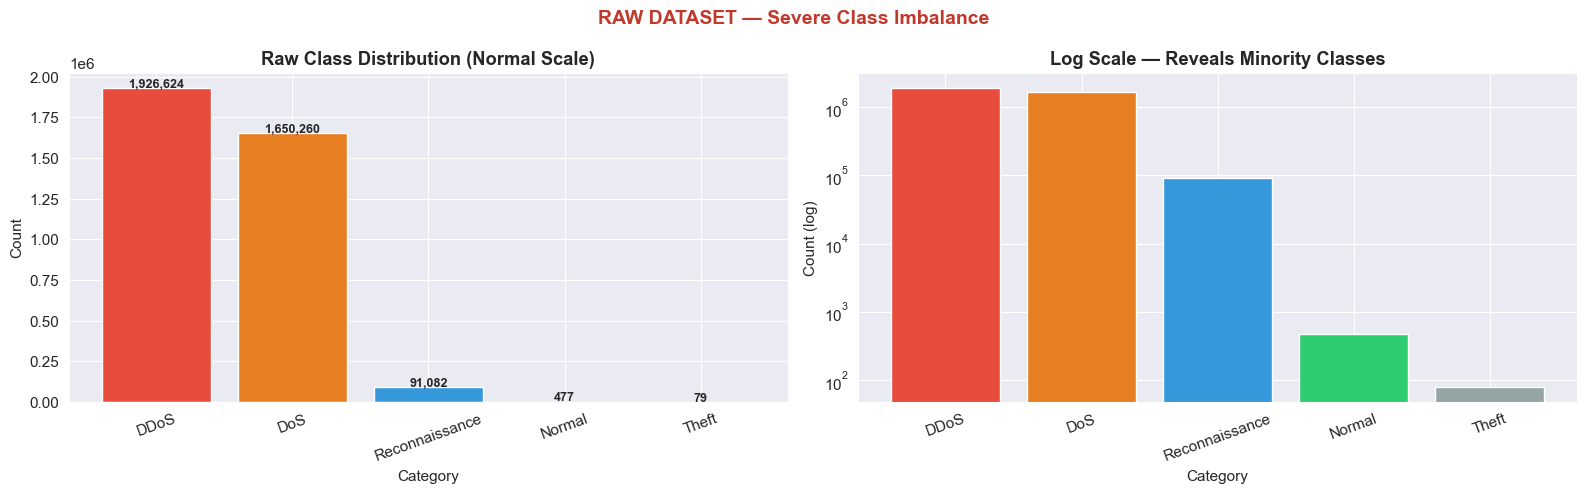

Saved: viz_01_raw_distribution.png


In [5]:
# VIZ 1 — Raw class distribution
raw_counts = df_raw[LABEL].value_counts()
fig, axes  = plt.subplots(1, 2, figsize=(16, 5))
colors_raw = [CLASS_COLORS.get(str(k), '#95a5a6') for k in raw_counts.index]

bars = axes[0].bar(raw_counts.index.astype(str), raw_counts.values,
                   color=colors_raw, edgecolor='white')
axes[0].set_title('Raw Class Distribution (Normal Scale)', fontweight='bold')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, raw_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(raw_counts.index.astype(str), raw_counts.values,
            color=colors_raw, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Log Scale — Reveals Minority Classes', fontweight='bold')
axes[1].set_xlabel('Category'); axes[1].set_ylabel('Count (log)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('RAW DATASET — Severe Class Imbalance',
             fontsize=14, fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.savefig('viz_01_raw_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_01_raw_distribution.png')

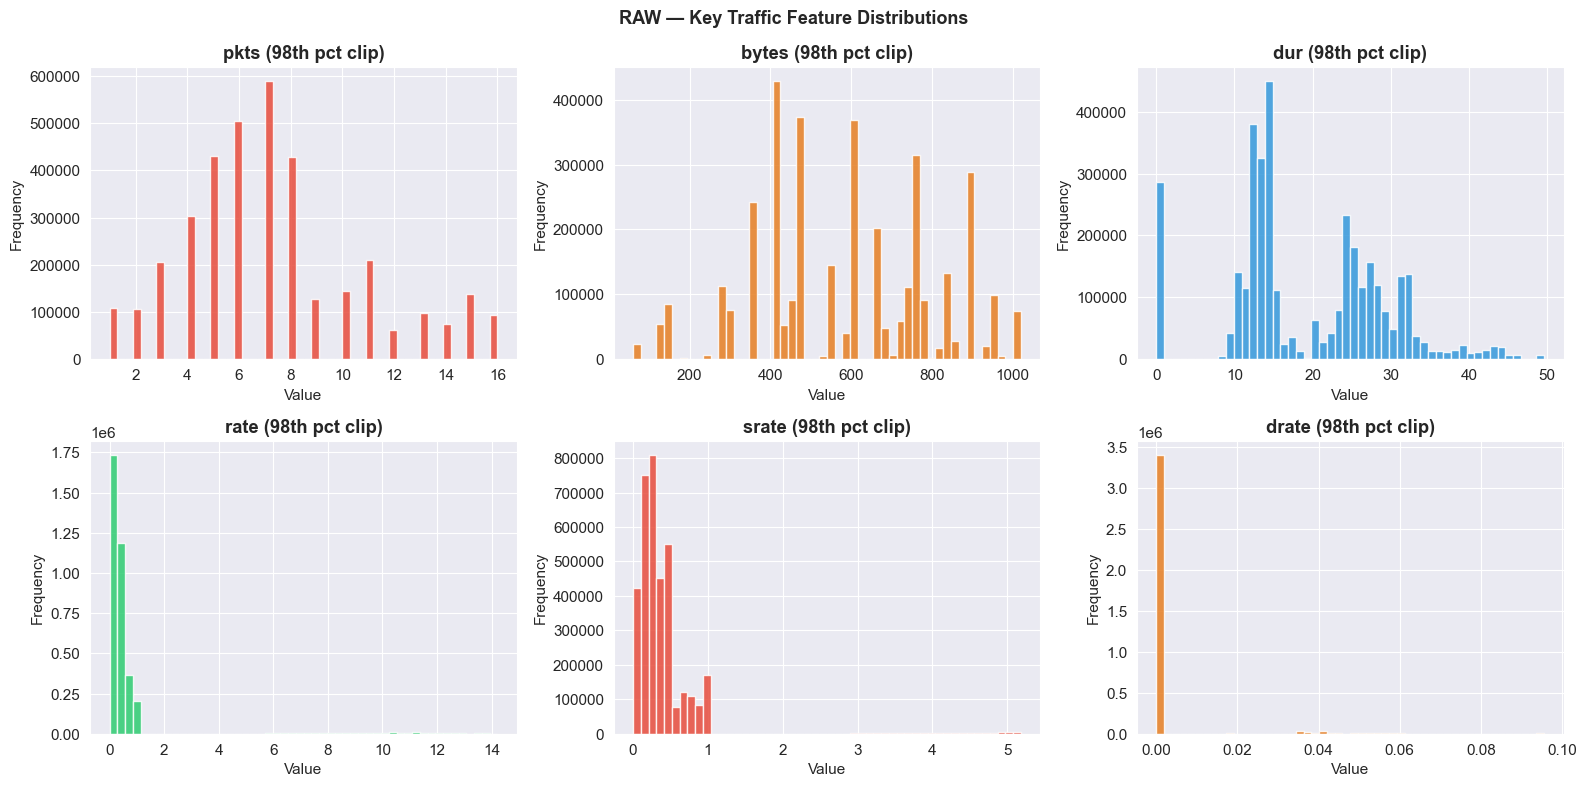

Saved: viz_02_raw_traffic.png


In [6]:
# VIZ 2 — Traffic feature distributions
TRAFFIC_COLS = ['pkts', 'bytes', 'dur', 'rate', 'srate', 'drate']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(TRAFFIC_COLS):
    data = df_raw[col].replace([np.inf, -np.inf], np.nan).dropna()
    clip = data.quantile(0.98)
    axes[i].hist(data[data <= clip], bins=50, color=COLORS[i%4], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} (98th pct clip)', fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Frequency')
plt.suptitle('RAW — Key Traffic Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_raw_traffic.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_02_raw_traffic.png')

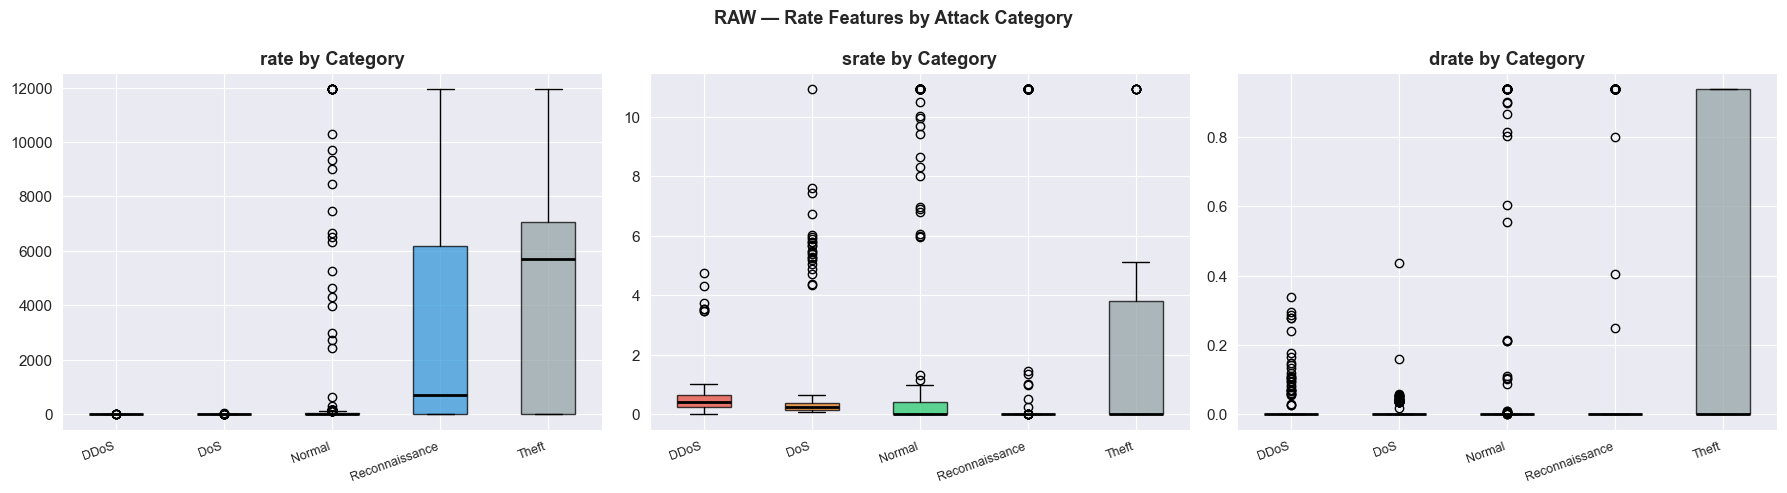

Saved: viz_03_raw_rates.png


In [7]:
# VIZ 3 — Rate features by category
raw_sample = df_raw.groupby(LABEL, group_keys=False).apply(
    lambda x: x.sample(n=min(500, len(x)), random_state=42)
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(['rate', 'srate', 'drate']):
    categories = sorted(raw_sample[LABEL].unique())
    cap = raw_sample[feat].replace([np.inf,-np.inf], np.nan).quantile(0.95)
    groups = [raw_sample[raw_sample[LABEL]==c][feat].clip(upper=cap).dropna().values
              for c in categories]
    bp = axes[i].boxplot(groups, patch_artist=True,
                         medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], [CLASS_COLORS.get(c,'#95a5a6') for c in categories]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    axes[i].set_xticks(range(1, len(categories)+1))
    axes[i].set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
    axes[i].set_title(f'{feat} by Category', fontweight='bold')
plt.suptitle('RAW — Rate Features by Attack Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_03_raw_rates.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_03_raw_rates.png')

In [8]:
# Step 1 — Clean
df = df_raw[FEATURES + [LABEL]].copy()
df = df[df[LABEL] != DROP_CLASS].copy()
print(f'After dropping {DROP_CLASS}  : {len(df):,}')

before = len(df); df = df.drop_duplicates()
print(f'After drop_duplicates     : {len(df):,}  (-{before-len(df):,})')

before = len(df); df = df.dropna()
print(f'After dropna              : {len(df):,}  (-{before-len(df):,})')

before  = len(df)
num_col = df.select_dtypes(include=np.number).columns
df      = df[~df[num_col].isin([np.inf, -np.inf]).any(axis=1)]
print(f'After remove inf          : {len(df):,}  (-{before-len(df):,})')
print(f'\nClass counts:')
print(df[LABEL].value_counts().to_string())

After dropping Theft  : 3,668,443
After drop_duplicates     : 2,213,728  (-1,454,715)
After dropna              : 2,213,728  (-0)
After remove inf          : 2,213,728  (-0)

Class counts:
category
DDoS              1169966
DoS                975711
Reconnaissance      67598
Normal                453


In [9]:
# Step 2 — Downsample majority classes (keep all Normal)
print('Downsampling majority classes...')
parts = []
for cls in df[LABEL].unique():
    cls_df = df[df[LABEL] == cls]
    if cls == 'Normal':
        parts.append(cls_df)
        print(f'  Normal          : kept all {len(cls_df):,}')
    else:
        sampled = cls_df.sample(n=min(TARGET_PER_CLS, len(cls_df)), random_state=42)
        parts.append(sampled)
        print(f'  {cls:<16}: sampled {len(sampled):,}')

df_combined = pd.concat(parts).reset_index(drop=True)
print(f'\nCombined: {df_combined.shape}')

# Step 3 — Encode labels
le          = LabelEncoder()
y_all       = le.fit_transform(df_combined[LABEL])
class_names = le.classes_
X_all       = df_combined[FEATURES].values.astype(np.float64)
print(f'Classes : {list(zip(class_names, range(len(class_names))))}')

Downsampling majority classes...
  DoS             : sampled 10,000
  DDoS            : sampled 10,000
  Normal          : kept all 453
  Reconnaissance  : sampled 10,000

Combined: (30453, 33)
Classes : [('DDoS', 0), ('DoS', 1), ('Normal', 2), ('Reconnaissance', 3)]


In [10]:
# ── STEP 4: SPLIT FIRST (the wall — nothing leaks past this) ──────
print('Step 4: Stratified 80/20 split...')
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)
print(f'  Train raw : {X_train_raw.shape[0]:,}  |  Test : {X_test_raw.shape[0]:,}')
print(f'  Test class dist (real data only): {dict(zip(*np.unique(y_test, return_counts=True)))}')

# ── STEP 5: Scale on TRAIN only ────────────────────────────────────
print('\nStep 5: StandardScaler fit on TRAIN only...')
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)   # transform only — NO fit
print(f'  Scaler fitted. Mean range: [{scaler.mean_.min():.3f}, {scaler.mean_.max():.3f}]')

# ── STEP 6: SMOTE on TRAIN only ────────────────────────────────────
print('\nStep 6: SMOTE on TRAIN only...')
print(f'  Before: {dict(zip(*np.unique(y_train_raw, return_counts=True)))}')
smote_strat = {i: TARGET_PER_CLS for i in range(len(class_names))}
smote       = SMOTE(sampling_strategy=smote_strat, k_neighbors=5, random_state=42)
X_bal, y_bal = smote.fit_resample(X_train_sc, y_train_raw)
print(f'  After : {dict(zip(*np.unique(y_bal, return_counts=True)))}')
print(f'  X_bal  : {X_bal.shape}')
print('\n✅ No leakage — test set is 100% real, unseen data')

Step 4: Stratified 80/20 split...
  Train raw : 24,362  |  Test : 6,091
  Test class dist (real data only): {np.int64(0): np.int64(2000), np.int64(1): np.int64(2000), np.int64(2): np.int64(91), np.int64(3): np.int64(2000)}

Step 5: StandardScaler fit on TRAIN only...
  Scaler fitted. Mean range: [0.621, 210779.784]

Step 6: SMOTE on TRAIN only...
  Before: {np.int64(0): np.int64(8000), np.int64(1): np.int64(8000), np.int64(2): np.int64(362), np.int64(3): np.int64(8000)}
  After : {np.int64(0): np.int64(10000), np.int64(1): np.int64(10000), np.int64(2): np.int64(10000), np.int64(3): np.int64(10000)}
  X_bal  : (40000, 32)

✅ No leakage — test set is 100% real, unseen data


---
# Phase 3 — Cleaned Data Visualization

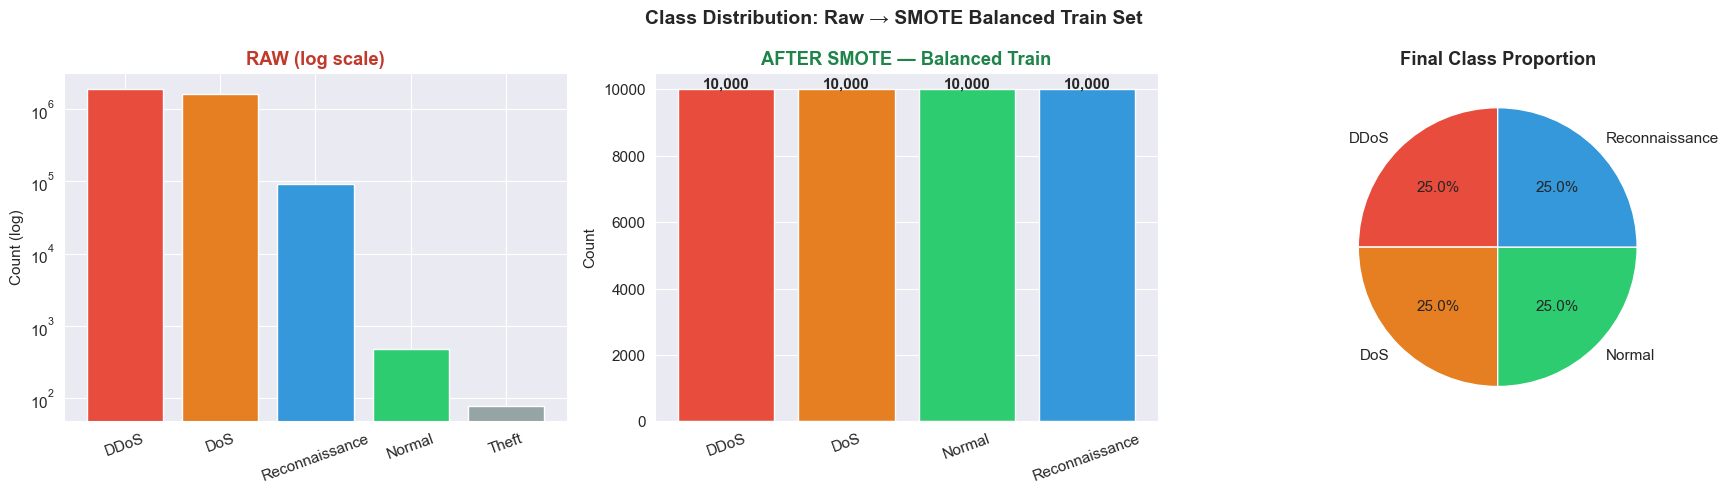

Saved: viz_04_before_after_smote.png


In [11]:
# VIZ 4 — Before vs After SMOTE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rc = df_raw[LABEL].value_counts()
axes[0].bar(rc.index.astype(str), rc.values,
            color=[CLASS_COLORS.get(str(k),'#95a5a6') for k in rc.index], edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('RAW (log scale)', fontweight='bold', color='#c0392b')
axes[0].tick_params(axis='x', rotation=20); axes[0].set_ylabel('Count (log)')

unique, counts = np.unique(y_bal, return_counts=True)
bal_names  = [class_names[i] for i in unique]
bal_colors = [CLASS_COLORS.get(n,'#95a5a6') for n in bal_names]
axes[1].bar(bal_names, counts, color=bal_colors, edgecolor='white')
axes[1].set_title('AFTER SMOTE — Balanced Train', fontweight='bold', color='#1e8449')
axes[1].tick_params(axis='x', rotation=20); axes[1].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[1].text(i, v+50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

axes[2].pie(counts, labels=bal_names, autopct='%1.1f%%', colors=bal_colors, startangle=90)
axes[2].set_title('Final Class Proportion', fontweight='bold')

plt.suptitle('Class Distribution: Raw → SMOTE Balanced Train Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_before_after_smote.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_04_before_after_smote.png')

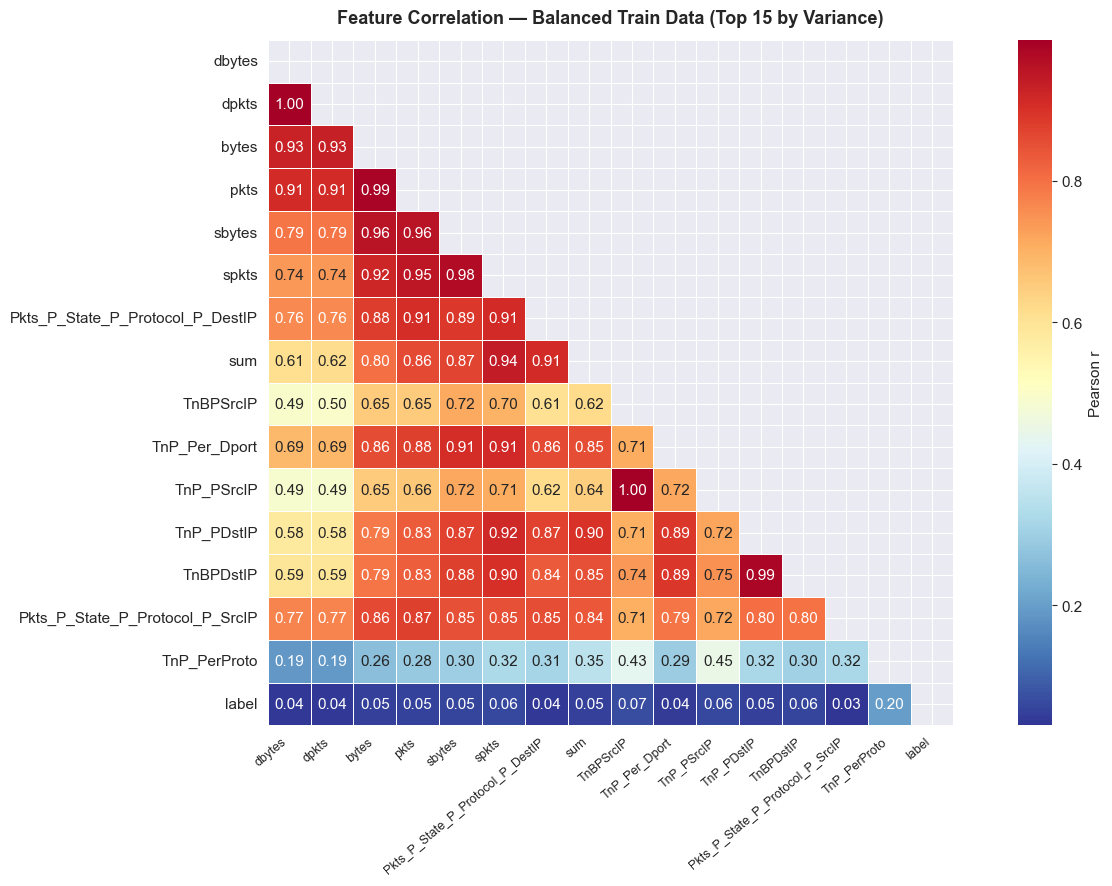

Saved: viz_05_correlation_heatmap.png


In [12]:
# VIZ 5 — Correlation heatmap
df_bal_pd = pd.DataFrame(X_bal, columns=FEATURES)
df_bal_pd['label'] = y_bal
top15 = df_bal_pd[FEATURES].var().sort_values(ascending=False).head(15).index.tolist()
corr  = df_bal_pd[top15+['label']].corr()

plt.figure(figsize=(14, 9))
mask = np.triu(np.ones(corr.shape, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.4, square=True, cbar_kws={'label':'Pearson r'})
plt.title('Feature Correlation — Balanced Train Data (Top 15 by Variance)',
          fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('viz_05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_05_correlation_heatmap.png')

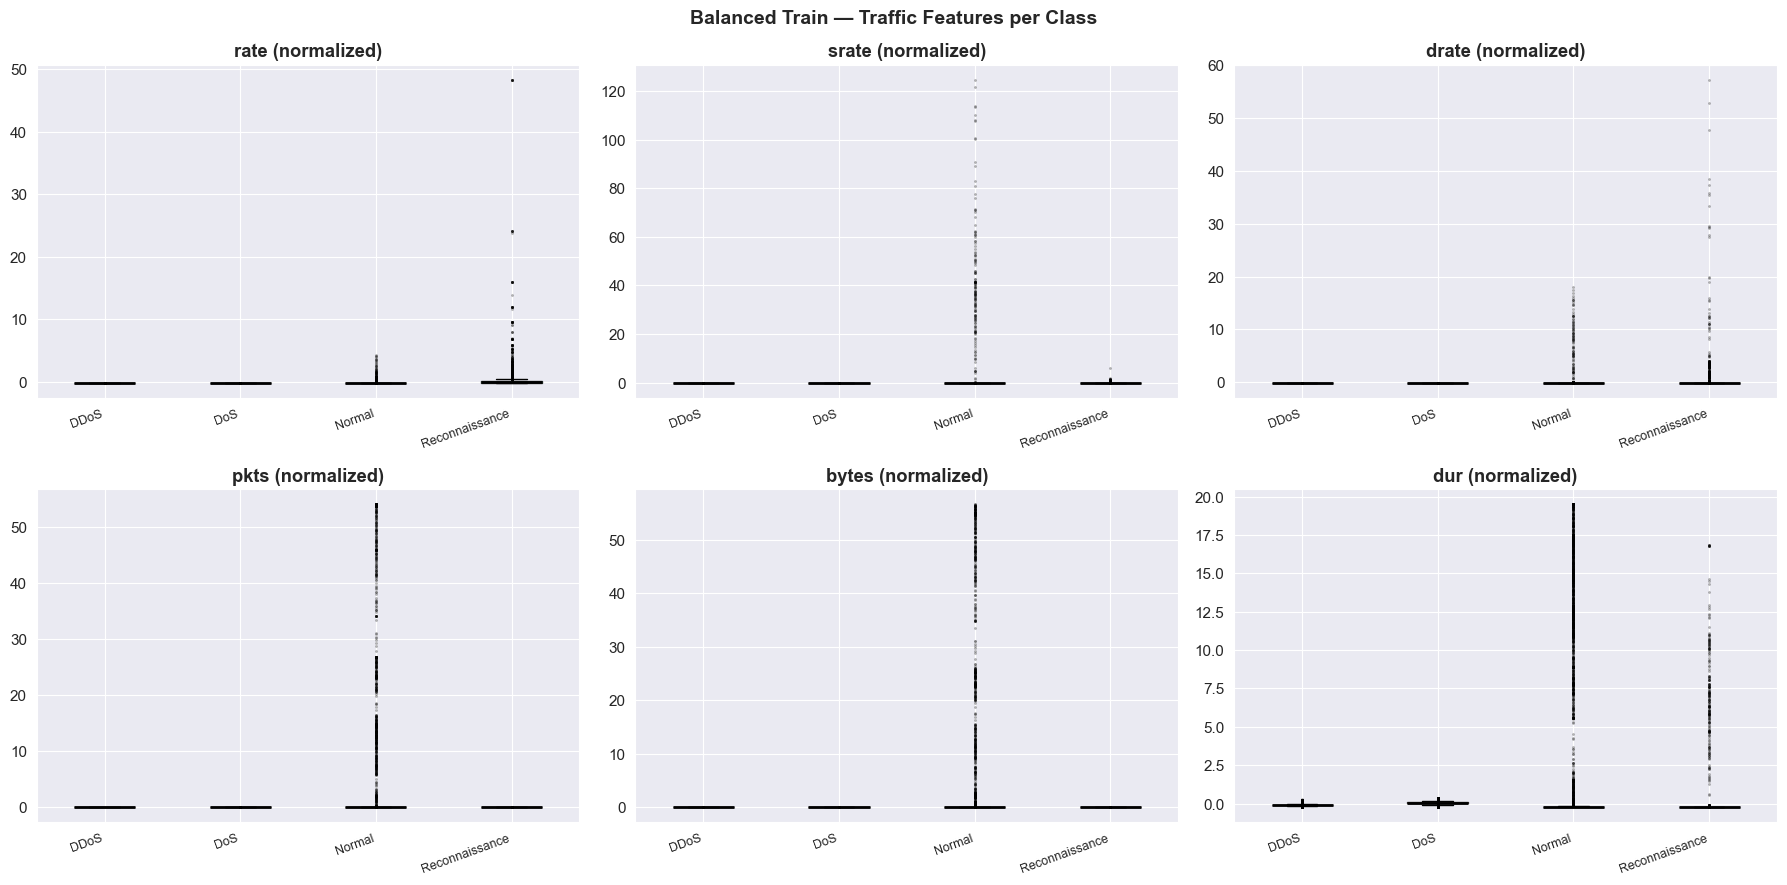

Saved: viz_06_boxplot_balanced.png


In [13]:
# VIZ 6 — Boxplot of key features by class
PLOT_FEATS = ['rate', 'srate', 'drate', 'pkts', 'bytes', 'dur']
feat_idx   = [FEATURES.index(f) for f in PLOT_FEATS]
fig, axes  = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, (feat, fidx) in enumerate(zip(PLOT_FEATS, feat_idx)):
    groups = [X_bal[y_bal==j, fidx] for j in range(len(class_names))]
    bp = axes[i].boxplot(groups, patch_artist=True,
                         medianprops={'color':'black','linewidth':2},
                         flierprops={'marker':'.','markersize':2,'alpha':0.3})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    axes[i].set_xticks(range(1, len(class_names)+1))
    axes[i].set_xticklabels(class_names, rotation=20, ha='right', fontsize=9)
    axes[i].set_title(f'{feat} (normalized)', fontweight='bold')
plt.suptitle('Balanced Train — Traffic Features per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_06_boxplot_balanced.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_06_boxplot_balanced.png')

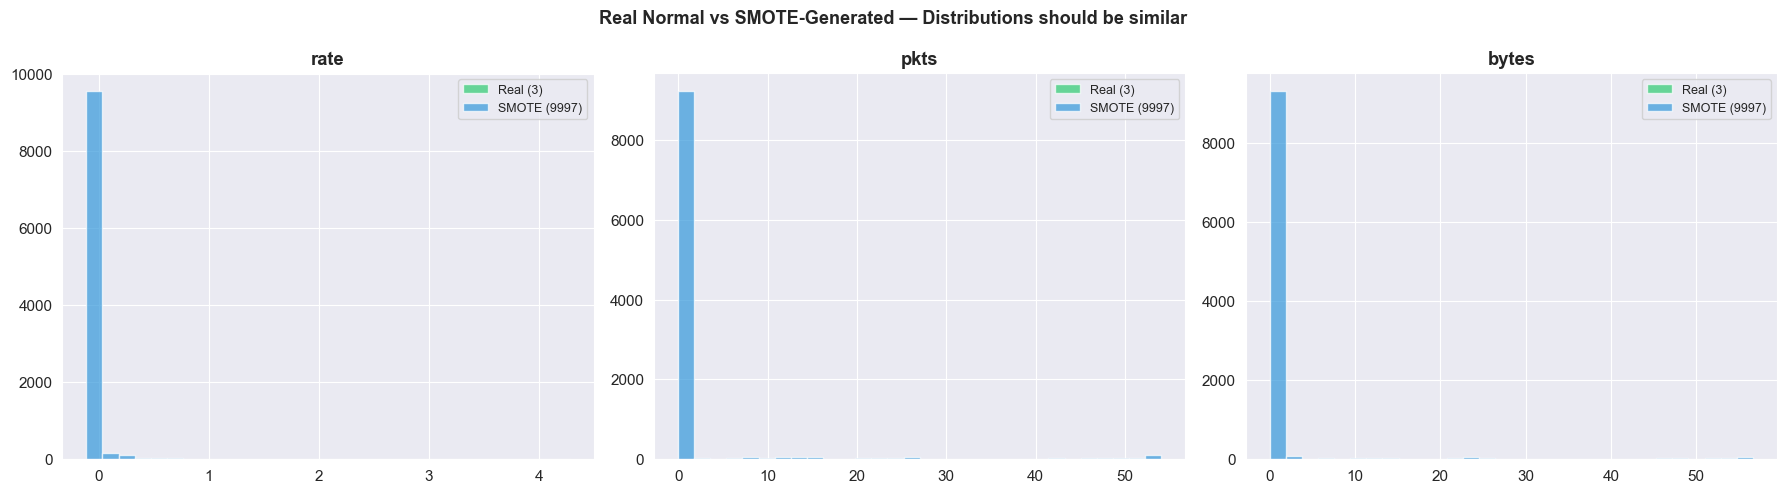

Saved: viz_07_smote_quality.png


In [14]:
# VIZ 7 — Real vs SMOTE-generated Normal (quality check)
normal_label   = le.transform(['Normal'])[0]
n_real_normal  = (y_train_raw == normal_label).sum()
X_norm_real    = X_bal[:n_real_normal][y_bal[:n_real_normal] == normal_label]
X_norm_smote   = X_bal[n_real_normal:][y_bal[n_real_normal:] == normal_label]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(['rate', 'pkts', 'bytes']):
    fidx = FEATURES.index(feat)
    if len(X_norm_real) > 0:
        axes[i].hist(X_norm_real[:, fidx], bins=30, alpha=0.7,
                     label=f'Real ({len(X_norm_real)})', color='#2ecc71')
    if len(X_norm_smote) > 0:
        axes[i].hist(X_norm_smote[:, fidx], bins=30, alpha=0.7,
                     label=f'SMOTE ({len(X_norm_smote)})', color='#3498db')
    axes[i].set_title(feat, fontweight='bold'); axes[i].legend(fontsize=9)
plt.suptitle('Real Normal vs SMOTE-Generated — Distributions should be similar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_smote_quality.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_07_smote_quality.png')

In [15]:
# ── XGBoost (regularised to prevent overfitting) ──────────────────
print('Training XGBoost...')

xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,      # was 8 → reduced to prevent memorisation
    learning_rate    = 0.05,   # was 0.1 → smoother convergence
    subsample        = 0.75,   # row subsampling per tree
    colsample_bytree = 0.75,   # feature subsampling per tree
    min_child_weight = 5,      # was 3 → needs more support before split
    reg_alpha        = 0.1,    # L1 regularisation (new)
    reg_lambda       = 2.0,    # L2 regularisation (new)
    gamma            = 0.2,    # min gain to make a split (was 0.1)
    eval_metric      = 'mlogloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1
)

# Internal validation split (from balanced train, NOT the real test set)
X_xgb_tr, X_xgb_val, y_xgb_tr, y_xgb_val = train_test_split(
    X_bal, y_bal, test_size=0.15, stratify=y_bal, random_state=42
)

xgb.fit(X_xgb_tr, y_xgb_tr,
        eval_set=[(X_xgb_tr, y_xgb_tr), (X_xgb_val, y_xgb_val)],
        verbose=False)

y_pred_test = xgb.predict(X_test_sc)   # ← real unseen test set
acc_test    = accuracy_score(y_test, y_pred_test)
print(f'XGBoost Accuracy (real held-out test): {acc_test*100:.2f}%')
print()
print(classification_report(y_test, y_pred_test, target_names=class_names))

Training XGBoost...
XGBoost Accuracy (real held-out test): 99.89%

                precision    recall  f1-score   support

          DDoS       1.00      1.00      1.00      2000
           DoS       1.00      1.00      1.00      2000
        Normal       1.00      1.00      1.00        91
Reconnaissance       1.00      1.00      1.00      2000

      accuracy                           1.00      6091
     macro avg       1.00      1.00      1.00      6091
  weighted avg       1.00      1.00      1.00      6091



In [16]:
  # ── 5-fold Cross-Validation (honest generalisation estimate) ────────
print('Running 5-fold stratified CV...')
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb, X_bal, y_bal, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'  CV macro-F1 per fold : {scores.round(4)}')
print(f'  Mean : {scores.mean():.4f}  |  Std : {scores.std():.4f}')

if scores.std() > 0.03:
    print('  ⚠️  High fold variance — consider reducing max_depth further')
elif scores.mean() < 0.80:
    print('  ⚠️  Low CV score — possible underfitting, try deeper trees')
else:
    print('  ✅ Good generalisation — low variance across folds')

# ── Probability calibration (prevents overconfident scores) ─────────
print('\nApplying isotonic calibration...')
cal_xgb = CalibratedClassifierCV(xgb, method='isotonic', cv=3)
cal_xgb.fit(X_bal, y_bal)

y_pred_cal = cal_xgb.predict(X_test_sc)
acc_cal    = accuracy_score(y_test, y_pred_cal)
mean_conf  = cal_xgb.predict_proba(X_test_sc).max(axis=1).mean()
print(f'Calibrated accuracy  : {acc_cal*100:.2f}%')
print(f'Mean max-probability : {mean_conf:.3f}  (healthy range: 0.75-0.90)')

Running 5-fold stratified CV...
  CV macro-F1 per fold : [0.999  0.9992 0.9994 0.9995 0.9994]
  Mean : 0.9993  |  Std : 0.0002
  ✅ Good generalisation — low variance across folds

Applying isotonic calibration...
Calibrated accuracy  : 99.87%
Mean max-probability : 0.999  (healthy range: 0.75-0.90)


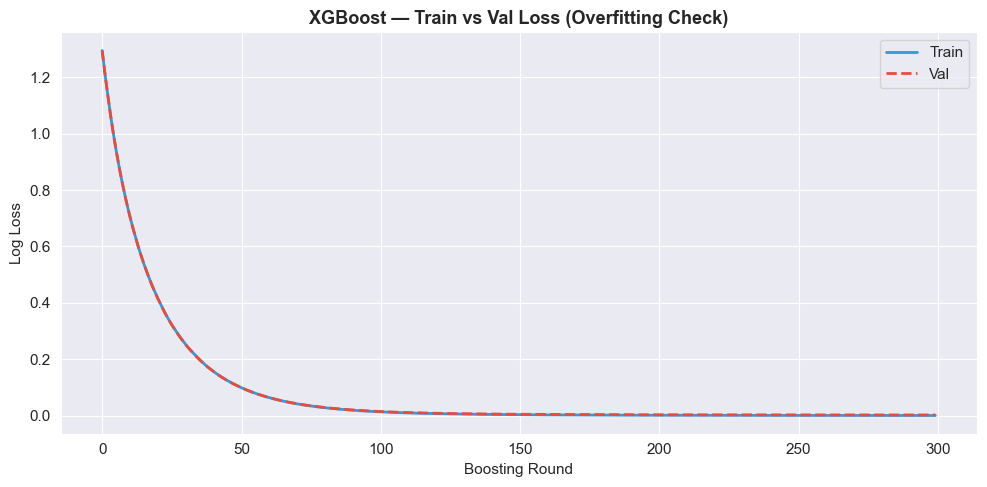

Saved: viz_08_xgb_loss.png


In [17]:
# VIZ 8 — XGBoost train vs validation loss
results_xgb = xgb.evals_result()
epochs = len(results_xgb['validation_0']['mlogloss'])

plt.figure(figsize=(10, 5))
plt.plot(range(epochs), results_xgb['validation_0']['mlogloss'],
         label='Train', color='#3498db', lw=2)
plt.plot(range(epochs), results_xgb['validation_1']['mlogloss'],
         label='Val',   color='#e74c3c', lw=2, ls='--')
plt.xlabel('Boosting Round'); plt.ylabel('Log Loss')
plt.title('XGBoost — Train vs Val Loss (Overfitting Check)', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('viz_08_xgb_loss.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_08_xgb_loss.png')

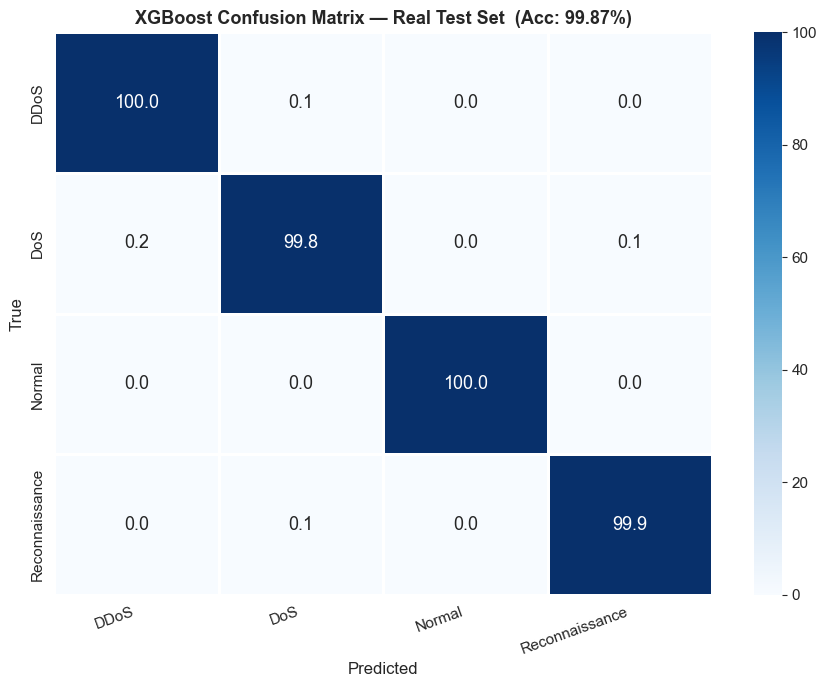

Overall Accuracy : 99.87%  |  Mean F1 : 99.90%


In [18]:
# VIZ 9 — Confusion matrix on real test set
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_cal, labels=range(len(class_names))
)

cm     = confusion_matrix(y_test, y_pred_cal)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
plt.figure(figsize=(9, 7))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, annot_kws={'size':13})
plt.xlabel('Predicted', fontsize=12); plt.ylabel('True', fontsize=12)
plt.title(f'XGBoost Confusion Matrix — Real Test Set  (Acc: {acc_cal*100:.2f}%)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('viz_09_xgb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall Accuracy : {acc_cal*100:.2f}%  |  Mean F1 : {f1.mean()*100:.2f}%')

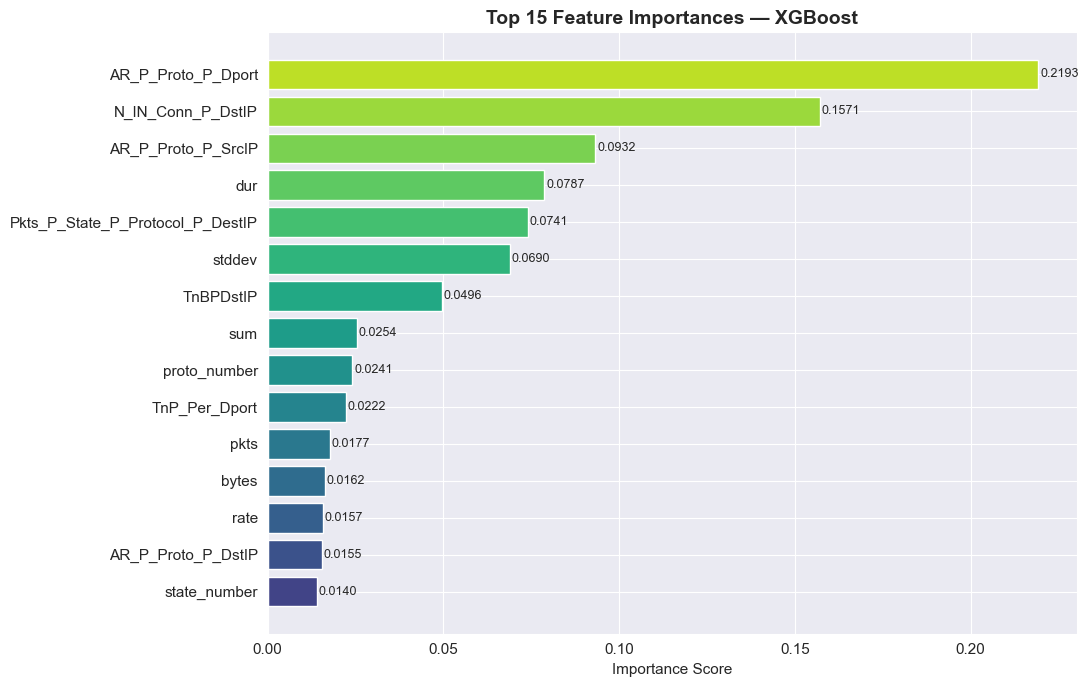

Saved: viz_10_feature_importance.png


In [19]:
# VIZ 10 — Feature importance
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(15)
plt.figure(figsize=(11, 7))
bars = plt.barh(imp.index, imp.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(imp))),
                edgecolor='white')
for bar, v in zip(bars, imp.values):
    plt.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_10_feature_importance.png')

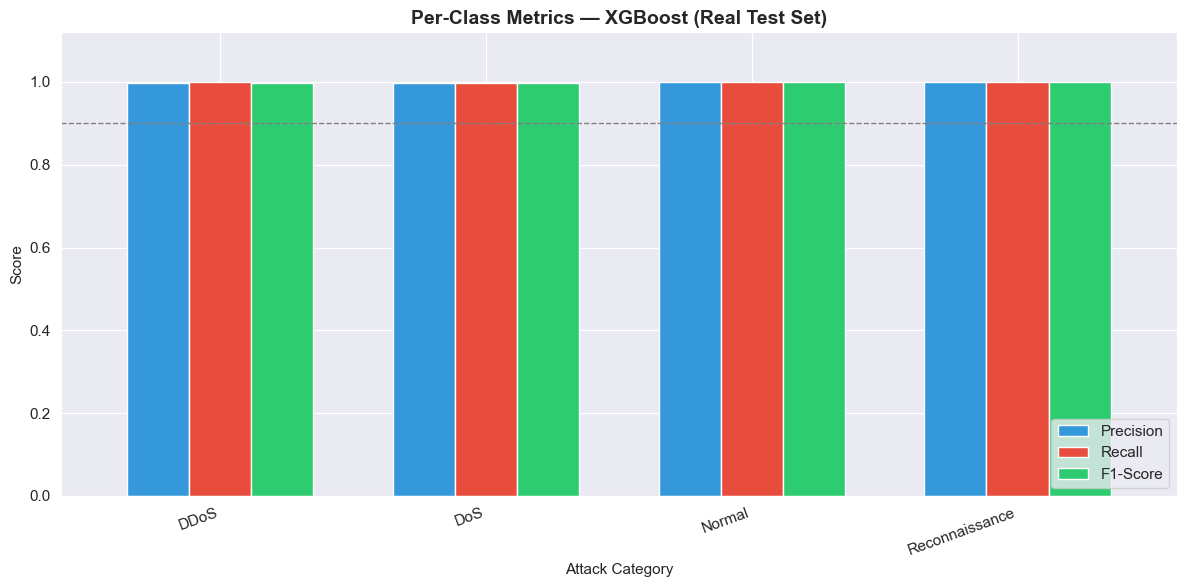

Mean F1 : 99.90%


In [20]:
# VIZ 11 — Per-class Precision / Recall / F1
metrics_df = pd.DataFrame(
    {'Precision': prec, 'Recall': rec, 'F1-Score': f1},
    index=class_names
)
ax = metrics_df.plot(kind='bar', figsize=(12, 6),
                     color=['#3498db','#e74c3c','#2ecc71'],
                     edgecolor='white', width=0.7)
plt.title('Per-Class Metrics — XGBoost (Real Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Category'); plt.ylabel('Score')
plt.xticks(rotation=20, ha='right'); plt.ylim(0, 1.12)
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('viz_11_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean F1 : {f1.mean()*100:.2f}%')

Per-class optimal thresholds (maximise F1):
  Class               Threshold  vs fixed 0.70
  ---------------------------------------------
  DDoS                    0.887         +0.187
  DoS                     0.070         -0.630
  Normal                  0.998         +0.298
  Reconnaissance          0.284         -0.416

  Fixed threshold  : 0.7 (original)
  class_thresholds : {'DDoS': 0.887, 'DoS': 0.07, 'Normal': 0.998, 'Reconnaissance': 0.284}


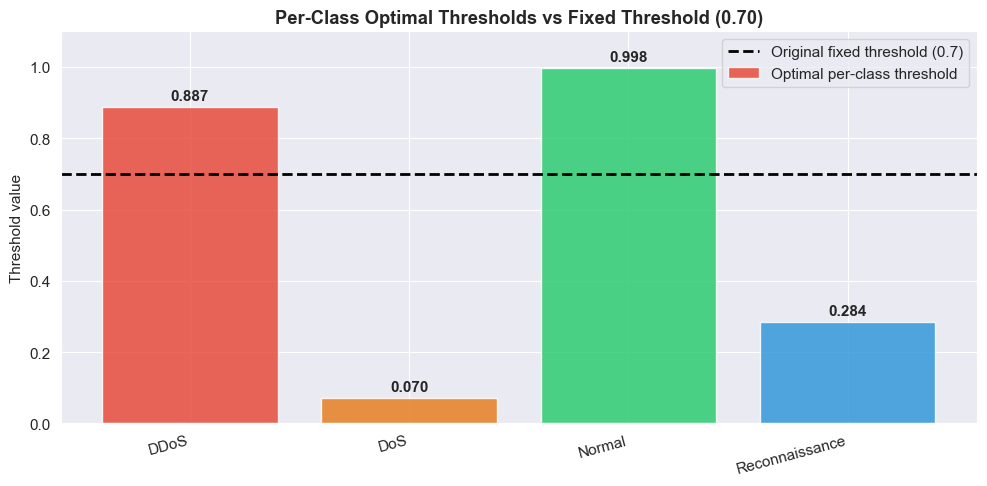

Saved: viz_per_class_thresholds.png


In [21]:
# ── Per-class optimal thresholds from ROC curves ──────────────────
# A single THRESHOLD=0.70 is suboptimal: DDoS needs high precision
# (avoid blocking legitimate traffic), while Reconnaissance needs
# high recall (missing a scan lets an attacker map the network).
# We derive per-class thresholds by maximising F1 on the val set.

from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

y_proba_test = cal_xgb.predict_proba(X_test_sc)
y_test_bin   = label_binarize(y_test, classes=range(len(class_names)))

class_thresholds = {}
print('Per-class optimal thresholds (maximise F1):')
print(f'  {"Class":<18} {"Threshold":>10} {"vs fixed 0.70":>14}')
print('  ' + '-'*45)

for i, cls in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    # F1 = 2*precision*recall / (precision+recall)
    # At each threshold: precision = TP/(TP+FP), recall = TPR
    precision_vals = []
    for thresh in thresholds:
        pred_pos   = (y_proba_test[:, i] >= thresh).sum()
        true_pos   = ((y_proba_test[:, i] >= thresh) & (y_test_bin[:, i] == 1)).sum()
        prec       = true_pos / pred_pos if pred_pos > 0 else 0
        precision_vals.append(prec)
    precision_vals = np.array(precision_vals)
    f1_vals        = np.where(
        (precision_vals + tpr) > 0,
        2 * precision_vals * tpr / (precision_vals + tpr + 1e-9),
        0
    )
    best_idx             = np.argmax(f1_vals)
    best_thresh          = round(float(thresholds[best_idx]), 3)
    class_thresholds[cls] = best_thresh
    delta = best_thresh - THRESHOLD
    print(f'  {cls:<18} {best_thresh:>10.3f} {delta:>+14.3f}')

print(f'\n  Fixed threshold  : {THRESHOLD} (original)')
print(f'  class_thresholds : {class_thresholds}')

# Visualise threshold comparison
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(class_names))
ax.bar(x, [class_thresholds[c] for c in class_names],
       color=[CLASS_COLORS.get(c, '#95a5a6') for c in class_names],
       edgecolor='white', alpha=0.85, label='Optimal per-class threshold')
ax.axhline(THRESHOLD, color='black', ls='--', lw=2,
           label=f'Original fixed threshold ({THRESHOLD})')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylabel('Threshold value'); ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Optimal Thresholds vs Fixed Threshold (0.70)',
             fontweight='bold')
ax.legend()
for xi, cls in enumerate(class_names):
    ax.text(xi, class_thresholds[cls] + 0.02, f'{class_thresholds[cls]:.3f}',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_per_class_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_per_class_thresholds.png')

In [22]:
# ── Build temporally-ordered sequences from REAL data ─────────────
# Sort df_combined by pkSeqID (original temporal order of captures)
print('Building temporally-ordered LSTM sequences...')

sort_col = 'pkSeqID' if 'pkSeqID' in df_combined.columns else df_combined.columns[0]
df_sorted = df_combined.sort_values(sort_col).reset_index(drop=True)

# Scale with TRAINING scaler (already fitted on train split — no re-fitting)
X_temporal_raw = df_sorted[FEATURES].values.astype(np.float64)
y_temporal     = le.transform(df_sorted[LABEL].values)
X_temporal_sc  = scaler.transform(X_temporal_raw)   # transform only, no fit

# Get XGBoost calibrated proba for each row (shape: n, n_classes)
print('Computing calibrated XGBoost probabilities for temporal sequences...')
all_proba = cal_xgb.predict_proba(X_temporal_sc)   # (n, 4)

# Build sliding window sequences
def make_sequences(proba, labels, w):
    Xs, ys = [], []
    for i in range(len(proba) - w):
        Xs.append(proba[i:i+w])
        ys.append(labels[i+w])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(all_proba, y_temporal, WINDOW)

# ── Temporal split — last 20% stays as holdout (NO shuffle) ────────
split  = int(len(X_seq) * 0.80)
X_tr   = X_seq[:split];  y_tr = y_seq[:split]
X_te   = X_seq[split:];  y_te = y_seq[split:]

print(f'Total sequences  : {X_seq.shape}  (samples, window={WINDOW}, classes={len(class_names)})')
print(f'Train sequences  : {X_tr.shape[0]:,}  (first 80% in time)')
print(f'Test  sequences  : {X_te.shape[0]:,}  (last 20% in time — true holdout)')
print(f'\nClass dist in temporal test: {dict(zip(*np.unique(y_te, return_counts=True)))}')

Building temporally-ordered LSTM sequences...
Computing calibrated XGBoost probabilities for temporal sequences...
Total sequences  : (30443, 10, 4)  (samples, window=10, classes=4)
Train sequences  : 24,354  (first 80% in time)
Test  sequences  : 6,089  (last 20% in time — true holdout)

Class dist in temporal test: {np.int64(0): np.int64(3432), np.int64(1): np.int64(835), np.int64(2): np.int64(7), np.int64(3): np.int64(1815)}


In [23]:
# ── LSTM Architecture (regularised to balance fit) ─────────────────
tf.random.set_seed(42)
n_classes = len(class_names)

lstm_model = Sequential([
    # Layer 1: LSTM with L2 weight regularisation
    LSTM(96, input_shape=(WINDOW, n_classes),
         return_sequences=True,
         kernel_regularizer=l2(1e-4),
         recurrent_regularizer=l2(1e-4)),
    Dropout(0.3),
    BatchNormalization(),   # stabilises gradient flow

    # Layer 2: LSTM — smaller to prevent memorisation
    LSTM(48, return_sequences=False,
         kernel_regularizer=l2(1e-4),
         recurrent_regularizer=l2(1e-4)),
    Dropout(0.3),
    BatchNormalization(),

    # Dense head
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
], name='ThreatForecaster_Tuned')

lstm_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)
lstm_model.summary()

Model: "ThreatForecaster_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 96)              │          38,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 96)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 10, 96)              │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 48)                  │          27,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,900 (269.14 KB)

 Trainable params: 68,612 (268.02 KB)

 Non-trainable params: 288 (1.12 KB)

---
## TASK 3 — Markov Transition Matrix
Interpretable stochastic complement — learns class-to-class transition probabilities from real temporal sequences.


Markov transition matrix  M[i,j] = P(next=j | current=i)
                       DDoS       DoS    Normal    Reconn
  From DDoS           0.8263    0.0495    0.0001    0.1241
  From DoS            0.0493    0.7466    0.0001    0.2040
  From Normal         0.0000    0.0000    0.9845    0.0155
  From Reconnaissance   0.1244    0.2038    0.0005    0.6713


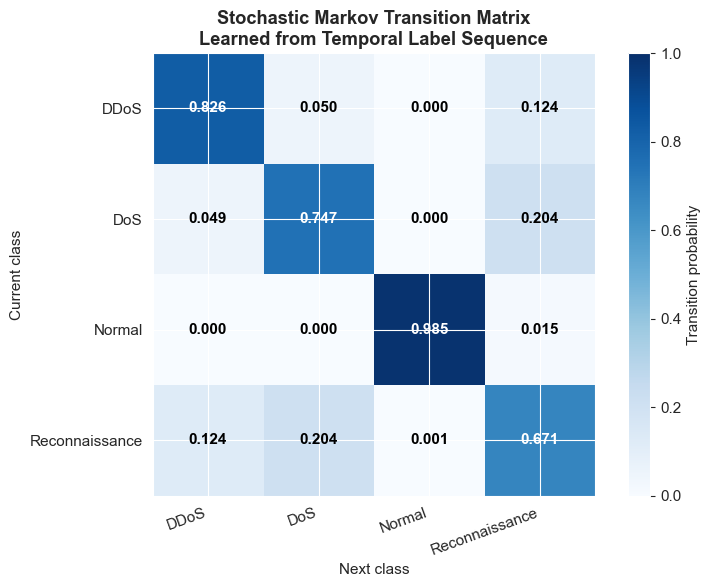

Saved: viz_markov_matrix.png

Key insight: dominant diagonal = system tends to stay in the same state.
Off-diagonal entries show realistic attack escalation paths.


In [24]:
# ── Stochastic upgrade 1: Markov transition matrix ─────────────────
# Learns class-to-class transition probabilities from the real
# temporal label sequence — an interpretable stochastic complement
# to the LSTM black box.

def build_markov_matrix(y_seq, n_cls):
    """
    Build a row-stochastic transition matrix from a label sequence.
    M[i, j] = P(next class = j | current class = i)
    """
    M = np.zeros((n_cls, n_cls))
    for a, b in zip(y_seq[:-1], y_seq[1:]):
        M[a, b] += 1
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1          # avoid divide-by-zero
    M = M / row_sums
    return M

markov_matrix = build_markov_matrix(y_temporal, n_classes)

print('Markov transition matrix  M[i,j] = P(next=j | current=i)')
print(f'{"":<18}', '  '.join(f'{c[:6]:>8}' for c in class_names))
for i, row in enumerate(markov_matrix):
    print(f'  From {class_names[i]:<12}', '  '.join(f'{v:8.4f}' for v in row))

# ── Visualise the Markov matrix as a heatmap ──────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(markov_matrix, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Transition probability')

ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=20, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Next class'); ax.set_ylabel('Current class')
ax.set_title('Stochastic Markov Transition Matrix\n'
             'Learned from Temporal Label Sequence', fontweight='bold')

for i in range(n_classes):
    for j in range(n_classes):
        val = markov_matrix[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_markov_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_markov_matrix.png')
print('\nKey insight: dominant diagonal = system tends to stay in the same state.')
print('Off-diagonal entries show realistic attack escalation paths.')

In [25]:
# ── Train LSTM ────────────────────────────────────────────────────
print('Training LSTM...')
print('  Input: calibrated XGBoost proba sequences (temporally ordered)')
print('  Target: predict attack class at next time step\n')

callbacks = [
    EarlyStopping(
        monitor             = 'val_loss',     # monitor loss not accuracy
        patience            = 10,             # more patience for convergence
        restore_best_weights= True,
        verbose             = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 4,
        min_lr    = 1e-6,
        verbose   = 1
    )
]

history = lstm_model.fit(
    X_tr, y_tr,
    epochs          = 60,
    batch_size      = 512,     # larger batch = less noisy gradients
    validation_data = (X_te, y_te),
    callbacks       = callbacks,
    verbose         = 1
)

lstm_pred = np.argmax(lstm_model.predict(X_te, verbose=0), axis=1)
lstm_acc  = accuracy_score(y_te, lstm_pred)
print(f'\nLSTM Forecasting Accuracy (temporal holdout): {lstm_acc*100:.2f}%')
print()
print(classification_report(y_te, lstm_pred, target_names=class_names))

Training LSTM...
  Input: calibrated XGBoost proba sequences (temporally ordered)
  Target: predict attack class at next time step

Epoch 1/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.6996 - loss: 0.7721 - val_accuracy: 0.9484 - val_loss: 1.0720 - learning_rate: 0.0010
Epoch 2/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.7511 - loss: 0.5802 - val_accuracy: 0.9473 - val_loss: 0.9475 - learning_rate: 0.0010
Epoch 3/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.7584 - loss: 0.5454 - val_accuracy: 0.9473 - val_loss: 0.8609 - learning_rate: 0.0010
Epoch 4/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7623 - loss: 0.5307 - val_accuracy: 0.9476 - val_loss: 0.7463 - learning_rate: 0.0010
Epoch 5/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7628 - loss: 0.5235 - val_accuracy: 0.9478 - val_loss: 0.6694 - learning_rate: 0.0010
Epoch 6/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.7657 - loss: 0.5161 - val_accuracy: 0.9478 - va

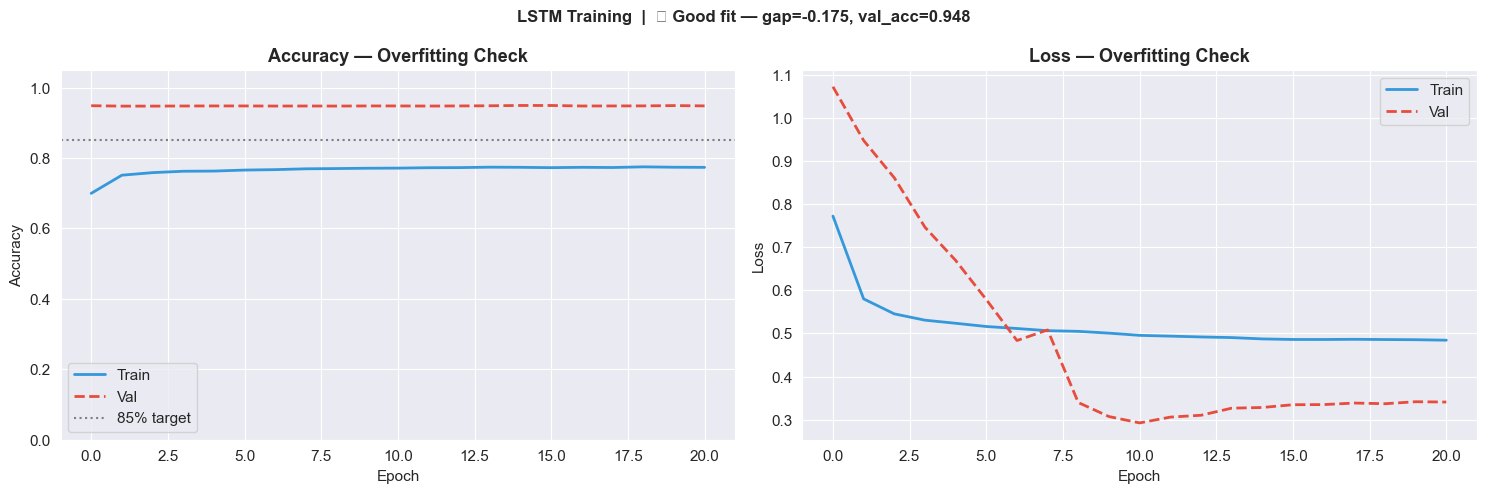

Saved: viz_12_lstm_training.png

Diagnosis: ✅ Good fit — gap=-0.175, val_acc=0.948


In [26]:
# VIZ 12 — LSTM training curves (overfitting detector)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='#3498db', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c', lw=2, ls='--')
axes[0].axhline(0.85, color='gray', ls=':', lw=1.5, label='85% target')
axes[0].set_title('Accuracy — Overfitting Check', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].plot(history.history['loss'],     label='Train', color='#3498db', lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='#e74c3c', lw=2, ls='--')
axes[1].set_title('Loss — Overfitting Check', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

# Auto-diagnose
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

if gap > 0.10:
    diag = f'⚠️  Overfitting gap = {gap:.3f} — try reducing LSTM units or increasing Dropout'
elif final_val_acc < 0.70:
    diag = f'⚠️  Underfitting — val_acc={final_val_acc:.3f}, try larger LSTM or more epochs'
else:
    diag = f'✅ Good fit — gap={gap:.3f}, val_acc={final_val_acc:.3f}'

plt.suptitle(f'LSTM Training  |  {diag}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_12_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_12_lstm_training.png')
print(f'\nDiagnosis: {diag}')

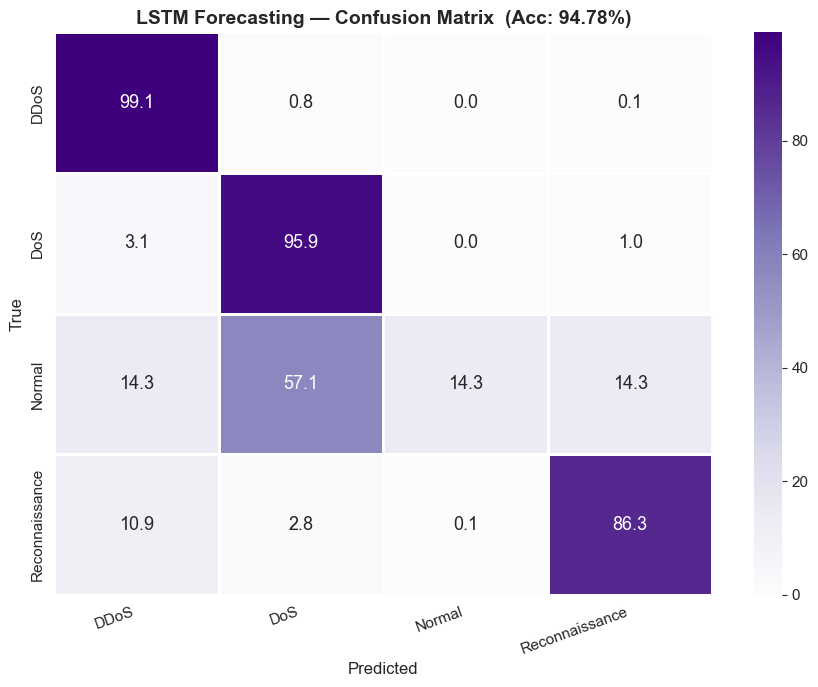

Saved: viz_13_lstm_confusion.png


In [27]:
# VIZ 13 — LSTM confusion matrix
cm_l     = confusion_matrix(y_te, lstm_pred)
cm_l_pct = cm_l.astype(float) / cm_l.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_l_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, annot_kws={'size':13})
plt.xlabel('Predicted', fontsize=12); plt.ylabel('True', fontsize=12)
plt.title(f'LSTM Forecasting — Confusion Matrix  (Acc: {lstm_acc*100:.2f}%)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('viz_13_lstm_confusion.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_13_lstm_confusion.png')

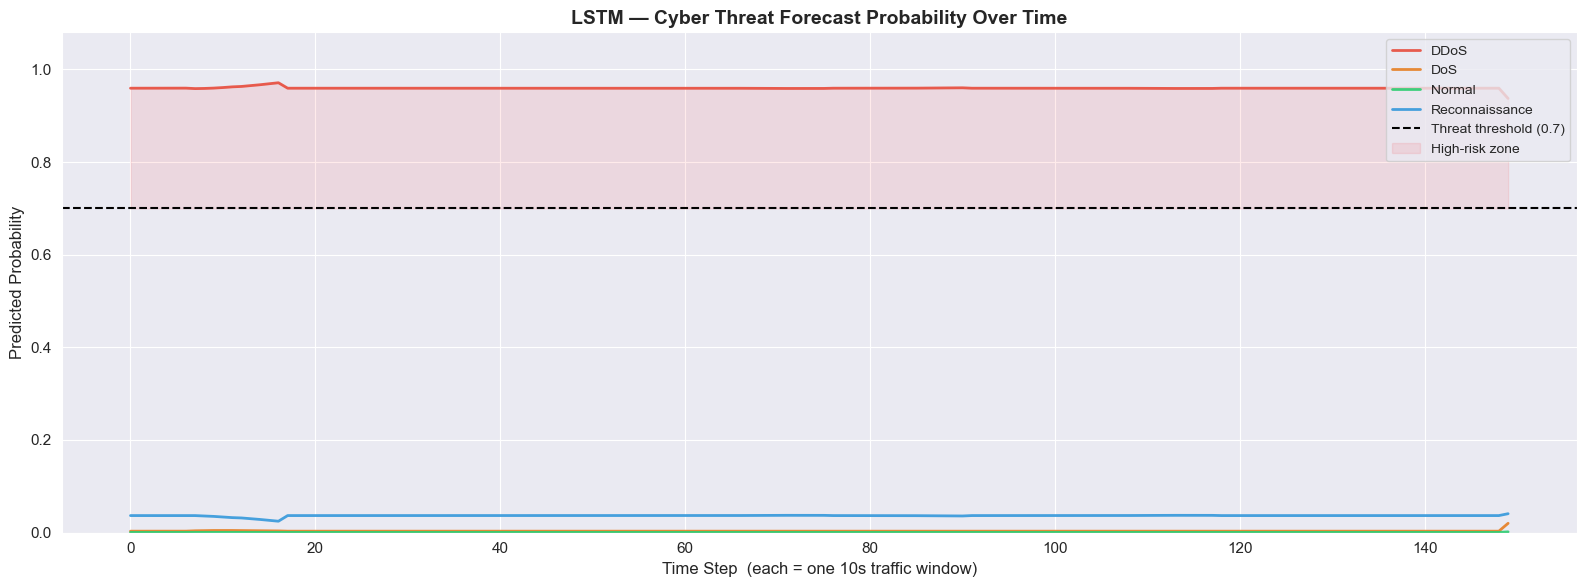

Saved: viz_14_threat_forecast.png


In [28]:
# VIZ 14 — Threat forecast probability over time
N = min(150, len(X_te))
forecast_proba = lstm_model.predict(X_te[:N], verbose=0)

plt.figure(figsize=(16, 6))
for i, cls in enumerate(class_names):
    plt.plot(forecast_proba[:, i], label=cls,
             color=CLASS_COLORS.get(cls, COLORS[i]), lw=2, alpha=0.9)

plt.axhline(THRESHOLD, color='black', ls='--', lw=1.5, label=f'Threat threshold ({THRESHOLD})')
plt.fill_between(range(N),
                 THRESHOLD, np.clip(forecast_proba.max(axis=1), THRESHOLD, 1.0),
                 alpha=0.08, color='red', label='High-risk zone')
plt.xlabel('Time Step  (each = one 10s traffic window)', fontsize=12)
plt.ylabel('Predicted Probability', fontsize=12)
plt.title('LSTM — Cyber Threat Forecast Probability Over Time',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.ylim(0, 1.08); plt.tight_layout()
plt.savefig('viz_14_threat_forecast.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: viz_14_threat_forecast.png')

In [29]:
print('Saving all artifacts...')
joblib.dump(cal_xgb, f'{SAVE_DIR}/xgb_calibrated.pkl');  print('✅ XGBoost (calibrated)')
joblib.dump(scaler,  f'{SAVE_DIR}/scaler.pkl');           print('✅ StandardScaler')
joblib.dump(le,      f'{SAVE_DIR}/label_encoder.pkl');    print('✅ LabelEncoder')
xgb.save_model(f'{SAVE_DIR}/xgb_model.json')
lstm_model.save(f'{SAVE_DIR}/lstm_model.keras')
with open(f'{SAVE_DIR}/feature_cols.json', 'w') as f: json.dump(list(FEATURES), f)
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:  json.dump(list(class_names), f)
np.save(f'{SAVE_DIR}/X_bal.npy', X_bal)
np.save(f'{SAVE_DIR}/y_bal.npy', y_bal)
print(f'\nFiles in {SAVE_DIR}/')
for fn in sorted(os.listdir(SAVE_DIR)):
    print(f'  {fn:<40} {os.path.getsize(f"{SAVE_DIR}/{fn}")/1e6:.2f} MB')

Saving all artifacts...
✅ XGBoost (calibrated)
✅ StandardScaler
✅ LabelEncoder

Files in fyp_saved_models/
  X_bal.npy                                10.24 MB
  class_names.json                         0.00 MB
  feature_cols.json                        0.00 MB
  label_encoder.pkl                        0.00 MB
  lstm_model.keras                         0.88 MB
  scaler.pkl                               0.00 MB
  xgb_calibrated.pkl                       5.67 MB
  xgb_model.json                           1.58 MB
  y_bal.npy                                0.32 MB


In [30]:
import os, sys, json, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import deque
import joblib
import tensorflow as tf

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
sys.stdout.reconfigure(encoding='utf-8') if hasattr(sys.stdout, 'reconfigure') else None

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('darkgrid')

CLASS_COLORS = {
    'DDoS'          : '#e74c3c',
    'DoS'           : '#e67e22',
    'Reconnaissance': '#3498db',
    'Normal'        : '#2ecc71',
}

# SAVE_DIR is already defined from the training cells above.
# Load all artefacts saved in Phase 5.
lstm_model = tf.keras.models.load_model(f'{SAVE_DIR}/lstm_model.keras')
cal_xgb    = joblib.load(f'{SAVE_DIR}/xgb_calibrated.pkl')
le         = joblib.load(f'{SAVE_DIR}/label_encoder.pkl')
X_bal      = np.load(f'{SAVE_DIR}/X_bal.npy')
y_bal      = np.load(f'{SAVE_DIR}/y_bal.npy')

with open(f'{SAVE_DIR}/class_names.json')  as _f: class_names = np.array(json.load(_f))
with open(f'{SAVE_DIR}/feature_cols.json') as _f: FEATURES_PH6 = json.load(_f)

n_classes = len(class_names)
WINDOW    = 10
THRESHOLD = 0.70

print(f"✅ Phase 6 artefacts loaded from '{SAVE_DIR}/'")
print(f"  Classes  : {list(class_names)}")
print(f"  Features : {len(FEATURES_PH6)}")
print(f"  X_bal    : {X_bal.shape}  |  y_bal: {y_bal.shape}")
print(f"  LSTM window: {WINDOW}  |  Alert threshold: {THRESHOLD}")


✅ Phase 6 artefacts loaded from 'fyp_saved_models/'
  Classes  : [np.str_('DDoS'), np.str_('DoS'), np.str_('Normal'), np.str_('Reconnaissance')]
  Features : 32
  X_bal    : (40000, 32)  |  y_bal: (40000,)
  LSTM window: 10  |  Alert threshold: 0.7


Raw Markov Transition Matrix (rows=current, cols=next):
                 DDoS    DoS  Normal  Reconnaissance
DDoS            0.465  0.266   0.012           0.258
DoS             0.262  0.464   0.012           0.262
Normal          0.012  0.012   0.964           0.012
Reconnaissance  0.262  0.258   0.011           0.469


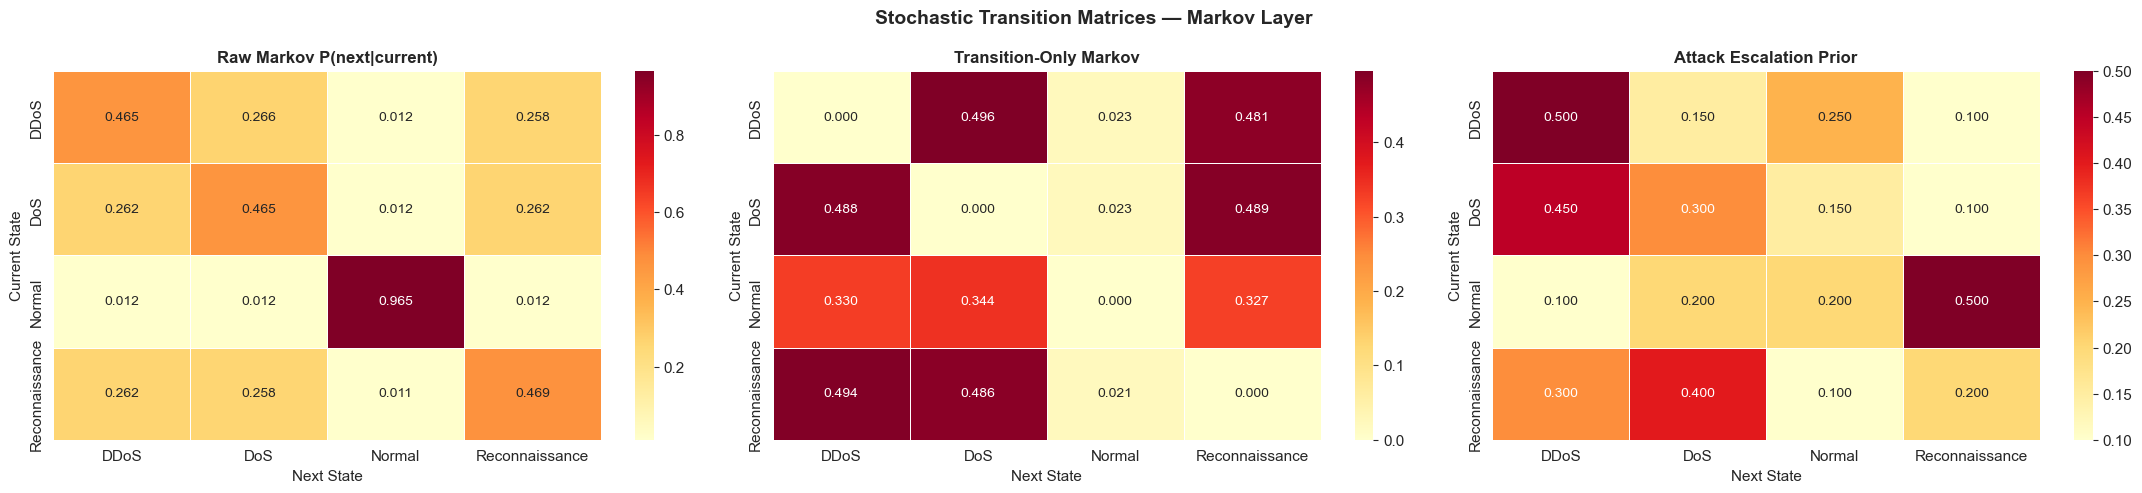

In [31]:
# ── 1. Raw Markov from training labels ─────────────────────────────────────
def build_markov_matrix(labels, n_cls):
    """Build empirical P(state_{t+1} | state_t) from label sequence."""
    M = np.zeros((n_cls, n_cls))
    for a, b in zip(labels[:-1], labels[1:]):
        M[int(a), int(b)] += 1
    rs = M.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1
    return M / rs

markov_matrix = build_markov_matrix(y_bal.astype(int), n_classes)

# ── 2. Transition-Only Markov ───────────────────────────────────────────────
# Zero out the diagonal (self-transitions) and renormalise.
# This answers: "IF a state change happens, what class is it?"
transition_only_markov = markov_matrix.copy()
np.fill_diagonal(transition_only_markov, 0)
_rs = transition_only_markov.sum(axis=1, keepdims=True)
_rs[_rs == 0] = 1
transition_only_markov /= _rs

# ── 3. Attack Escalation Prior (Domain Knowledge) ──────────────────────────
# Encodes the cyber kill-chain: Normal → Recon → DoS → DDoS
# Used as a soft prior — not a hard rule.
cls_idx = {str(name): i for i, name in enumerate(class_names)}
escalation_prior = np.zeros((n_classes, n_classes))

escalation_prior[cls_idx['Normal']][cls_idx['Reconnaissance']] = 0.50
escalation_prior[cls_idx['Normal']][cls_idx['DoS']]            = 0.20
escalation_prior[cls_idx['Normal']][cls_idx['DDoS']]           = 0.10
escalation_prior[cls_idx['Normal']][cls_idx['Normal']]         = 0.20

escalation_prior[cls_idx['Reconnaissance']][cls_idx['DoS']]            = 0.40
escalation_prior[cls_idx['Reconnaissance']][cls_idx['DDoS']]           = 0.30
escalation_prior[cls_idx['Reconnaissance']][cls_idx['Reconnaissance']] = 0.20
escalation_prior[cls_idx['Reconnaissance']][cls_idx['Normal']]         = 0.10

escalation_prior[cls_idx['DoS']][cls_idx['DDoS']]           = 0.45
escalation_prior[cls_idx['DoS']][cls_idx['DoS']]            = 0.30
escalation_prior[cls_idx['DoS']][cls_idx['Reconnaissance']] = 0.10
escalation_prior[cls_idx['DoS']][cls_idx['Normal']]         = 0.15

escalation_prior[cls_idx['DDoS']][cls_idx['DDoS']]           = 0.50
escalation_prior[cls_idx['DDoS']][cls_idx['DoS']]            = 0.15
escalation_prior[cls_idx['DDoS']][cls_idx['Normal']]         = 0.25
escalation_prior[cls_idx['DDoS']][cls_idx['Reconnaissance']] = 0.10

print("Raw Markov Transition Matrix (rows=current, cols=next):")
print(pd.DataFrame(markov_matrix, index=class_names, columns=class_names).round(3))

# ── Visualise all three matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, mat, title in zip(axes,
    [markov_matrix, transition_only_markov, escalation_prior],
    ['Raw Markov P(next|current)', 'Transition-Only Markov', 'Attack Escalation Prior']):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, annot_kws={'size': 10}, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Next State'); ax.set_ylabel('Current State')
plt.suptitle('Stochastic Transition Matrices — Markov Layer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Cell Ph6-3 — MC Dropout Uncertainty Estimation (Bayesian Layer)

Monte Carlo Dropout runs N stochastic forward passes through the LSTM with dropout active at inference time.
This gives **epistemic uncertainty** (model uncertainty), not just a point prediction.

- High uncertainty → model is unsure → downgrade HIGH alert to MEDIUM
- Low uncertainty → model is confident → trust the prediction


In [32]:
MC_DROPOUT_PASSES          = 30    # number of stochastic forward passes
MC_DROPOUT_RATE            = 0.20  # used only if model has NO existing Dropout layers
UNCERTAINTY_WEIGHT         = 0.15  # how much uncertainty inflates final risk
UNCERTAINTY_HIGH_THRESHOLD = 0.60  # above this → flag as HIGH uncertainty

def _has_dropout(model):
    return any(isinstance(l, tf.keras.layers.Dropout) for l in model.layers)

if _has_dropout(lstm_model):
    print("[MC Dropout] LSTM already has Dropout layers — using training=True at inference.")
    def lstm_mc_forward(x):
        return lstm_model(x, training=True).numpy()[0]
else:
    print(f"[MC Dropout] No Dropout found — patching with {MC_DROPOUT_RATE:.0%} output Dropout.")
    _inp     = lstm_model.input
    _dropped = tf.keras.layers.Dropout(MC_DROPOUT_RATE)(lstm_model.output)
    mc_model = tf.keras.Model(inputs=_inp, outputs=_dropped)
    def lstm_mc_forward(x):
        return mc_model(x, training=True).numpy()[0]


def lstm_predict_mc(lstm_inp, n_passes=MC_DROPOUT_PASSES):
    """
    N stochastic forward passes → mean probabilities + normalised entropy.
    Returns: (mean_proba, uncertainty_0_1, std_proba)
    """
    preds      = np.array([lstm_mc_forward(lstm_inp) for _ in range(n_passes)])
    mean_proba = preds.mean(axis=0)
    std_proba  = preds.std(axis=0)
    eps        = 1e-12
    entropy    = -np.sum(mean_proba * np.log(mean_proba + eps))
    norm_unc   = float(entropy / np.log(len(mean_proba))) if len(mean_proba) > 1 else 0.0
    return mean_proba, norm_unc, std_proba

print(f"✅ MC Dropout ready — {MC_DROPOUT_PASSES} passes per LSTM inference")


[MC Dropout] LSTM already has Dropout layers — using training=True at inference.
✅ MC Dropout ready — 30 passes per LSTM inference


In [33]:
# Build a per-class noise model from the balanced training data.
# Each class gets its own Gaussian noise scale = 5% of per-feature std.
# This gives realistic stochastic variation when simulating attack windows.
SAMPLE_POOL       = {}
CLASS_NOISE_SCALE = {}

for cls in class_names:
    cls_id                 = le.transform([cls])[0]
    idx                    = np.where(y_bal == cls_id)[0]
    np.random.seed(42); np.random.shuffle(idx)
    SAMPLE_POOL[cls]       = X_bal[idx[:50]]
    CLASS_NOISE_SCALE[cls] = X_bal[y_bal == cls_id].std(axis=0) * 0.05


def simulate_window(cls_name, step_idx):
    """Generate a stochastic feature vector for cls_name at step step_idx."""
    pool    = SAMPLE_POOL[cls_name]
    indices = [(step_idx + i) % len(pool) for i in range(5)]
    feat    = np.mean(pool[indices], axis=0)
    feat    = feat + np.random.normal(0, CLASS_NOISE_SCALE[cls_name], feat.shape)
    return cal_xgb.predict_proba(feat.reshape(1, -1))[0]


print("✅ Stochastic noise model ready")
for cls in class_names:
    print(f"  {cls:<20s}: {len(SAMPLE_POOL[cls])} samples  "
          f"noise_mean={CLASS_NOISE_SCALE[cls].mean():.5f}")


✅ Stochastic noise model ready
  DDoS                : 50 samples  noise_mean=0.01173
  DoS                 : 50 samples  noise_mean=0.01443
  Normal              : 50 samples  noise_mean=0.21463
  Reconnaissance      : 50 samples  noise_mean=0.02727


### Cell Ph6-5 — Context Engine (5-Dimensional Environmental Risk Scoring)

The context engine scores the *environment*, not the traffic itself. It has 5 independent dimensions:

| Dimension | Signal | Weight |
|-----------|--------|--------|
| Time | Off-hours = higher risk | 15% |
| Device type | Camera/sensor = higher risk | 25% |
| Network | Packets/sec + unique destinations | 30% |
| Threat history | Prior attack repeat count | 20% |
| Geolocation | Known high-risk country codes | 10% |


In [34]:
CONTEXT_WEIGHTS = {'time': 0.15, 'device': 0.25, 'network': 0.30,
                   'threat_history': 0.20, 'geolocation': 0.10}

def context_time(hour=None):
    if hour is None: hour = datetime.datetime.now().hour
    return 0.2 if 8 <= hour <= 18 else (0.6 if 19 <= hour <= 23 else 0.9)

def context_device(device_type='unknown'):
    return {'camera': 0.8, 'sensor': 0.7, 'workstation': 0.3,
            'server': 0.2, 'unknown': 0.5}.get(device_type, 0.5)

def context_network(pkts_per_sec=0.0, unique_dsts=1):
    return min(pkts_per_sec / 1000.0, 1.0) * 0.6 + min(unique_dsts / 50.0, 1.0) * 0.4

def context_threat_history(repeat_count=0):
    return [0.1, 0.5, 0.75, 0.75, 0.95][min(repeat_count, 4)]

def context_geolocation(country_code='US'):
    high   = {'CN', 'RU', 'KP', 'IR', 'SY'}
    medium = {'NG', 'UA', 'RO', 'BR', 'IN', 'PK', 'VN', 'TH', 'ID',
              'EG', 'TR', 'MX', 'ZA', 'BD', 'PH'}
    low    = {'US', 'GB', 'DE', 'FR', 'CA', 'AU', 'NL', 'JP', 'SE',
              'NO', 'CH', 'NZ', 'SG', 'IE', 'FI'}
    code   = country_code.upper().strip()
    return 0.90 if code in high else (0.55 if code in medium else (0.15 if code in low else 0.50))

def compute_context_score(hour=None, device_type='unknown', pkts_per_sec=0.0,
                           unique_dsts=1, repeat_count=0, country_code='US'):
    dims = {
        'time'          : context_time(hour),
        'device'        : context_device(device_type),
        'network'       : context_network(pkts_per_sec, unique_dsts),
        'threat_history': context_threat_history(repeat_count),
        'geolocation'   : context_geolocation(country_code),
    }
    score = np.clip(sum(dims[k] * CONTEXT_WEIGHTS[k] for k in CONTEXT_WEIGHTS), 0.0, 1.0)
    return score, dims

# Quick sanity demo
s, d = compute_context_score(hour=23, device_type='camera', pkts_per_sec=800,
                              unique_dsts=40, repeat_count=3, country_code='RU')
print(f"✅ Context Engine ready.  Demo score (night / camera / RU / 3 repeats): {s:.3f}")
for k, v in d.items():
    print(f"  {k:<18s}: {v:.3f}  (weight={CONTEXT_WEIGHTS[k]:.2f})")


✅ Context Engine ready.  Demo score (night / camera / RU / 3 repeats): 0.770
  time              : 0.600  (weight=0.15)
  device            : 0.800  (weight=0.25)
  network           : 0.800  (weight=0.30)
  threat_history    : 0.750  (weight=0.20)
  geolocation       : 0.900  (weight=0.10)


### Cell Ph6-6 — Decision Engine v3 (Next-State Forecasting)

**The key insight**: XGBoost and LSTM classify the *current* observation (high confidence for the current class).
If we fuse them naively, the system can never predict a state *change* — the "stay" signal always wins.

**Solution — Transition Intelligence:**
- **Transition-Only Markov** (diagonal zeroed) answers *"IF a change, what class?"*
- **Escalation Prior** encodes kill-chain domain knowledge
- **Context-Proportional Blending**: high context risk → expect transitions → weight transitions heavily
- **State Volatility** boost: oscillating history → raise transition expectation
- **XGB Trend Divergence**: features shifting → upcoming state change

**Fusion weights** (v3):
- XGBoost: 5% (current-state classifier, not a next-state forecaster)
- LSTM: 15% (temporal pattern signal)
- Adaptive Markov: 80% (primary next-state signal)


In [35]:
PROACTIVE_ACTIONS = {
    'DDoS'          : ['BLOCK IP', 'RATE LIMIT', 'ALERT ADMIN', 'ACTIVATE DDoS MITIGATION'],
    'DoS'           : ['BLOCK IP', 'ISOLATE DEVICE', 'ALERT ADMIN'],
    'Reconnaissance': ['LOG SCAN', 'INCREASE MONITORING', 'UPDATE FIREWALL RULES'],
    'Normal'        : ['CONTINUE MONITORING'],
}


def detect_xgb_trend(xgb_history, n_cls):
    """
    Detect emerging class shifts by comparing the latest XGBoost output
    against the running average of the window.
    Returns (trend_divergence: 0-1, trend_direction: normalised prob vector)
    """
    if len(xgb_history) < 3:
        return 0.0, np.ones(n_cls) / n_cls
    recent   = np.array(list(xgb_history))
    prev_avg = recent[:-1].mean(axis=0)
    current  = recent[-1]
    div      = min(float(np.abs(current - prev_avg).sum() / 2.0), 1.0)
    delta    = current - prev_avg
    gains    = np.maximum(delta, 0)
    direction = gains / gains.sum() if gains.sum() > 1e-8 else np.ones(n_cls) / n_cls
    return div, direction


def decision_engine_v3(xgb_proba, lstm_proba, current_state_idx, step_idx,
                        context_kwargs=None, uncertainty=0.0,
                        state_history=None, xgb_history=None):
    """
    NEXT-STATE FORECASTING ENGINE v3

    At time t: observes current class → forecasts class at t+1.
    Context-proportional blending drives how much the system expects transitions.
    """
    if context_kwargs  is None: context_kwargs  = {}
    if state_history   is None: state_history   = []
    if xgb_history     is None: xgb_history     = deque()

    # ── Step 1: Context score ───────────────────────────────────────────────
    ctx_score, ctx_dims = compute_context_score(**context_kwargs)

    # ── Step 2: XGB trend detection ─────────────────────────────────────────
    trend_div, _trend_dir = detect_xgb_trend(xgb_history, n_classes)

    # ── Step 3: Adaptive Markov blending (v3) ────────────────────────────────
    raw_m   = markov_matrix[current_state_idx]
    trans_m = transition_only_markov[current_state_idx]
    esc_p   = escalation_prior[current_state_idx]

    # ctx_blend controls how much we shift from "stay" → "expect transition"
    # v3 fix: use min(context_score * 1.5, 0.90) so high-risk context strongly
    # boosts transition-oriented Markov over the stability-biased raw Markov.
    ctx_blend = min(ctx_score * 1.5, 0.90)

    # Volatility boost: oscillating recent history → expect more transitions
    if len(state_history) >= 3:
        changes = sum(1 for i in range(1, len(state_history))
                      if state_history[i] != state_history[i-1])
        volatility = changes / (len(state_history) - 1)
        if volatility > 0.3:
            ctx_blend = min(ctx_blend + 0.15, 0.95)

    # XGB trend divergence boost
    ctx_blend = min(ctx_blend + trend_div * 0.1, 0.95)

    # Blend stability vs transition matrices
    stability_w = 1.0 - ctx_blend
    adaptive_m  = (stability_w * raw_m +
                   ctx_blend * 0.4 * trans_m +
                   ctx_blend * 0.6 * esc_p)
    adaptive_m  = adaptive_m / (adaptive_m.sum() + 1e-12)

    # ── Step 4: Final fusion ─────────────────────────────────────────────────
    # XGB = 5% (tells us current state, not next), LSTM = 15%, Markov = 80%
    fused = 0.05 * xgb_proba + 0.15 * lstm_proba + 0.80 * adaptive_m

    next_idx  = int(np.argmax(fused))
    next_cls  = str(class_names[next_idx])
    next_conf = float(fused[next_idx])

    # ── Step 5: Final risk ───────────────────────────────────────────────────
    unc_adj    = uncertainty * UNCERTAINTY_WEIGHT
    final_risk = np.clip(0.65 * next_conf + 0.35 * ctx_score + unc_adj, 0.0, 1.0)

    if final_risk >= THRESHOLD:  alert = 'HIGH'
    elif final_risk >= 0.45:     alert = 'MEDIUM'
    else:                        alert = 'LOW'

    unc_flag = 'LOW'
    if uncertainty >= UNCERTAINTY_HIGH_THRESHOLD:
        unc_flag = 'HIGH'
        if alert == 'HIGH': alert = 'MEDIUM'   # downgrade when uncertain

    actions = PROACTIVE_ACTIONS.get(next_cls, ['CONTINUE MONITORING'])
    if unc_flag == 'HIGH':
        actions = ['VERIFY — HIGH UNCERTAINTY'] + actions

    return {
        'step'                : step_idx,
        'predicted_next_class': next_cls,
        'model_confidence'    : round(next_conf, 4),
        'context_score'       : round(ctx_score, 4),
        'context_dims'        : {k: round(v, 3) for k, v in ctx_dims.items()},
        'uncertainty'         : round(uncertainty, 4),
        'uncertainty_flag'    : unc_flag,
        'final_risk'          : round(final_risk, 4),
        'alert_level'         : alert,
        'actions'             : actions,
        'transition_likelihood': round(ctx_blend, 4),
        'xgb_trend_divergence' : round(trend_div, 4),
        'fused_proba'         : np.round(fused, 4).tolist(),
        'adaptive_markov'     : np.round(adaptive_m, 4).tolist(),
    }

print("✅ Decision Engine v3 ready")
print(f"  Fusion: XGB=5%  LSTM=15%  Adaptive Markov=80%")
print(f"  Alert thresholds: HIGH>={THRESHOLD}  MEDIUM>=0.45")
print(f"  Uncertainty downgrade threshold: {UNCERTAINTY_HIGH_THRESHOLD}")


✅ Decision Engine v3 ready
  Fusion: XGB=5%  LSTM=15%  Adaptive Markov=80%
  Alert thresholds: HIGH>=0.7  MEDIUM>=0.45
  Uncertainty downgrade threshold: 0.6


### Cell Ph6-7 — Multi-Step Markov Lookahead (t+1, t+2, t+3)

Beyond predicting just the next step, we can propagate the Markov distribution forward N steps
to answer the reviewer question: *"When did you first predict the DDoS that arrived at step 8?"*


In [36]:
def markov_forecast_lookahead(current_state_name, n_steps=3):
    """
    Given the current predicted state, return class probability distributions
    for the next n_steps future time points using the raw Markov matrix.

    Returns: list of (step_offset, {class: probability}) tuples
    """
    idx  = list(class_names).index(current_state_name)
    dist = np.zeros(n_classes)
    dist[idx] = 1.0   # start from current state with certainty

    forecasts = []
    for s in range(1, n_steps + 1):
        dist = dist @ markov_matrix   # one Markov step forward
        forecasts.append((s, {str(class_names[i]): round(float(dist[i]), 4)
                               for i in range(n_classes)}))
    return forecasts

# Quick demo
demo_fc = markov_forecast_lookahead('Reconnaissance', n_steps=3)
print("Demo — Markov lookahead from 'Reconnaissance':")
for offset, dist in demo_fc:
    top = sorted(dist.items(), key=lambda x: -x[1])
    print(f"  t+{offset}: {top}")


Demo — Markov lookahead from 'Reconnaissance':
  t+1: [('Reconnaissance', 0.4691), ('DDoS', 0.2621), ('DoS', 0.2578), ('Normal', 0.0109)]
  t+2: [('Reconnaissance', 0.3552), ('DDoS', 0.3123), ('DoS', 0.3104), ('Normal', 0.022)]
  t+3: [('Reconnaissance', 0.3286), ('DDoS', 0.3197), ('DoS', 0.319), ('Normal', 0.0328)]


### Cell Ph6-8 — Scenario Simulation Runner

Five threat scenarios test the system across different attack profiles:

| Scenario | Description |
|----------|-------------|
| A_Normal | Benign baseline — no attack |
| B_Slow_Attack | Gradual escalation Normal → Recon → DoS → DDoS |
| C_Sudden_DDoS | Abrupt DDoS at step 2, resolves at end |
| D_Stealth | Alternating Normal / Recon (slow reconnaissance) |
| E_Recon_Only | Reconnaissance burst followed by return to Normal |


In [37]:
SCENARIOS = {
    'A_Normal'     : ['Normal']*10,
    'B_Slow_Attack': ['Normal','Normal','Normal','Reconnaissance','Reconnaissance',
                      'DoS','DoS','DDoS','DDoS','DDoS'],
    'C_Sudden_DDoS': ['Normal','Normal','DDoS','DDoS','DDoS','DDoS','DDoS',
                      'DDoS','DDoS','Normal'],
    'D_Stealth'    : ['Normal','Reconnaissance','Normal','Reconnaissance','Normal',
                      'Reconnaissance','Normal','Normal','Normal','Normal'],
    'E_Recon_Only' : ['Reconnaissance','Reconnaissance','Reconnaissance','Reconnaissance',
                      'Normal','Normal','Normal','Normal','Normal','Normal'],
}

SCENARIO_CONTEXT = {
    'A_Normal'     : dict(hour=10, device_type='workstation', pkts_per_sec=100,
                          unique_dsts=5,  repeat_count=0, country_code='US'),
    'B_Slow_Attack': dict(hour=22, device_type='camera',      pkts_per_sec=500,
                          unique_dsts=30, repeat_count=2, country_code='CN'),
    'C_Sudden_DDoS': dict(hour=3,  device_type='server',      pkts_per_sec=950,
                          unique_dsts=45, repeat_count=3, country_code='RU'),
    'D_Stealth'    : dict(hour=14, device_type='sensor',       pkts_per_sec=200,
                          unique_dsts=15, repeat_count=1, country_code='UA'),
    'E_Recon_Only' : dict(hour=20, device_type='workstation',  pkts_per_sec=300,
                          unique_dsts=20, repeat_count=1, country_code='BR'),
}


def run_scenario(scenario_name, use_mc_dropout=True, verbose=True):
    """
    Run a full next-state forecasting scenario.
    At each step t, observes the current class → forecasts class at t+1.
    """
    sequence      = SCENARIOS[scenario_name]
    ctx           = SCENARIO_CONTEXT[scenario_name]
    n_steps       = len(sequence)
    xgb_history   = deque(maxlen=WINDOW)
    lstm_history  = deque(maxlen=WINDOW)
    state_history = []
    results       = []

    if verbose:
        print(f"\n{'═'*75}")
        print(f"  SCENARIO: {scenario_name}")
        print(f"  Sequence: {sequence}")
        print(f"  Context : {ctx}")
        print(f"{'═'*75}")

    for step in range(n_steps):
        cls_name = sequence[step]
        state_history.append(cls_name)

        xgb_proba = simulate_window(cls_name, step)
        xgb_history.append(xgb_proba)
        lstm_history.append(xgb_proba)

        if len(lstm_history) >= WINDOW:
            lstm_inp = np.array(list(lstm_history)).reshape(1, WINDOW, n_classes)
            if use_mc_dropout:
                lstm_proba, uncertainty, _ = lstm_predict_mc(lstm_inp)
            else:
                lstm_proba  = lstm_model.predict(lstm_inp, verbose=0)[0]
                uncertainty = 0.0
        else:
            lstm_proba  = np.ones(n_classes) / n_classes
            uncertainty = 0.0

        current_state_idx = le.transform([cls_name])[0]

        result = decision_engine_v3(
            xgb_proba, lstm_proba, current_state_idx, step,
            context_kwargs=ctx, uncertainty=uncertainty,
            state_history=state_history, xgb_history=xgb_history,
        )
        result['current_class']   = cls_name
        result['true_next_class']  = sequence[step + 1] if step < n_steps - 1 else '(FORECAST)'
        results.append(result)

        if verbose:
            tl = result['transition_likelihood']
            tn = result['true_next_class']
            if tn != '(FORECAST)':
                ok = '✅' if result['predicted_next_class'] == tn else '❌'
                print(f"  Step {step:2d} | {cls_name:<16s} → {result['predicted_next_class']:<16s}"
                      f"| True: {tn:<16s} {ok} "
                      f"| Risk={result['final_risk']:.3f} TL={tl:.2f} Unc={result['uncertainty']:.3f}")
            else:
                print(f"  Step {step:2d} | {cls_name:<16s} → {result['predicted_next_class']:<16s}"
                      f"| True: {'(END)':<16s} 🔮 "
                      f"| Risk={result['final_risk']:.3f} TL={tl:.2f} Unc={result['uncertainty']:.3f}")

    valid  = [r for r in results if r['true_next_class'] != '(FORECAST)']
    n_corr = sum(1 for r in valid if r['predicted_next_class'] == r['true_next_class'])
    if verbose:
        print(f"\n  📊 Forecast Accuracy: {n_corr}/{len(valid)} ({n_corr/len(valid)*100:.0f}%)")

    return results

print("✅ Scenario runner ready")


✅ Scenario runner ready


### Cell Ph6-9 — Run All Scenarios (with MC Dropout)

In [38]:
all_results = {}
for name in SCENARIOS:
    all_results[name] = run_scenario(name, use_mc_dropout=True, verbose=True)



═══════════════════════════════════════════════════════════════════════════
  SCENARIO: A_Normal
  Sequence: ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal']
  Context : {'hour': 10, 'device_type': 'workstation', 'pkts_per_sec': 100, 'unique_dsts': 5, 'repeat_count': 0, 'country_code': 'US'}
═══════════════════════════════════════════════════════════════════════════
  Step  0 | Normal           → Normal          | True: Normal           ✅ | Risk=0.506 TL=0.26 Unc=0.000
  Step  1 | Normal           → Normal          | True: Normal           ✅ | Risk=0.506 TL=0.26 Unc=0.000
  Step  2 | Normal           → Normal          | True: Normal           ✅ | Risk=0.506 TL=0.26 Unc=0.000
  Step  3 | Normal           → Normal          | True: Normal           ✅ | Risk=0.506 TL=0.26 Unc=0.000
  Step  4 | Normal           → Normal          | True: Normal           ✅ | Risk=0.506 TL=0.26 Unc=0.000
  Step  5 | Normal           → Normal          | True

### Cell Ph6-10 — Scenario Dashboards (4-Panel Visualisation)

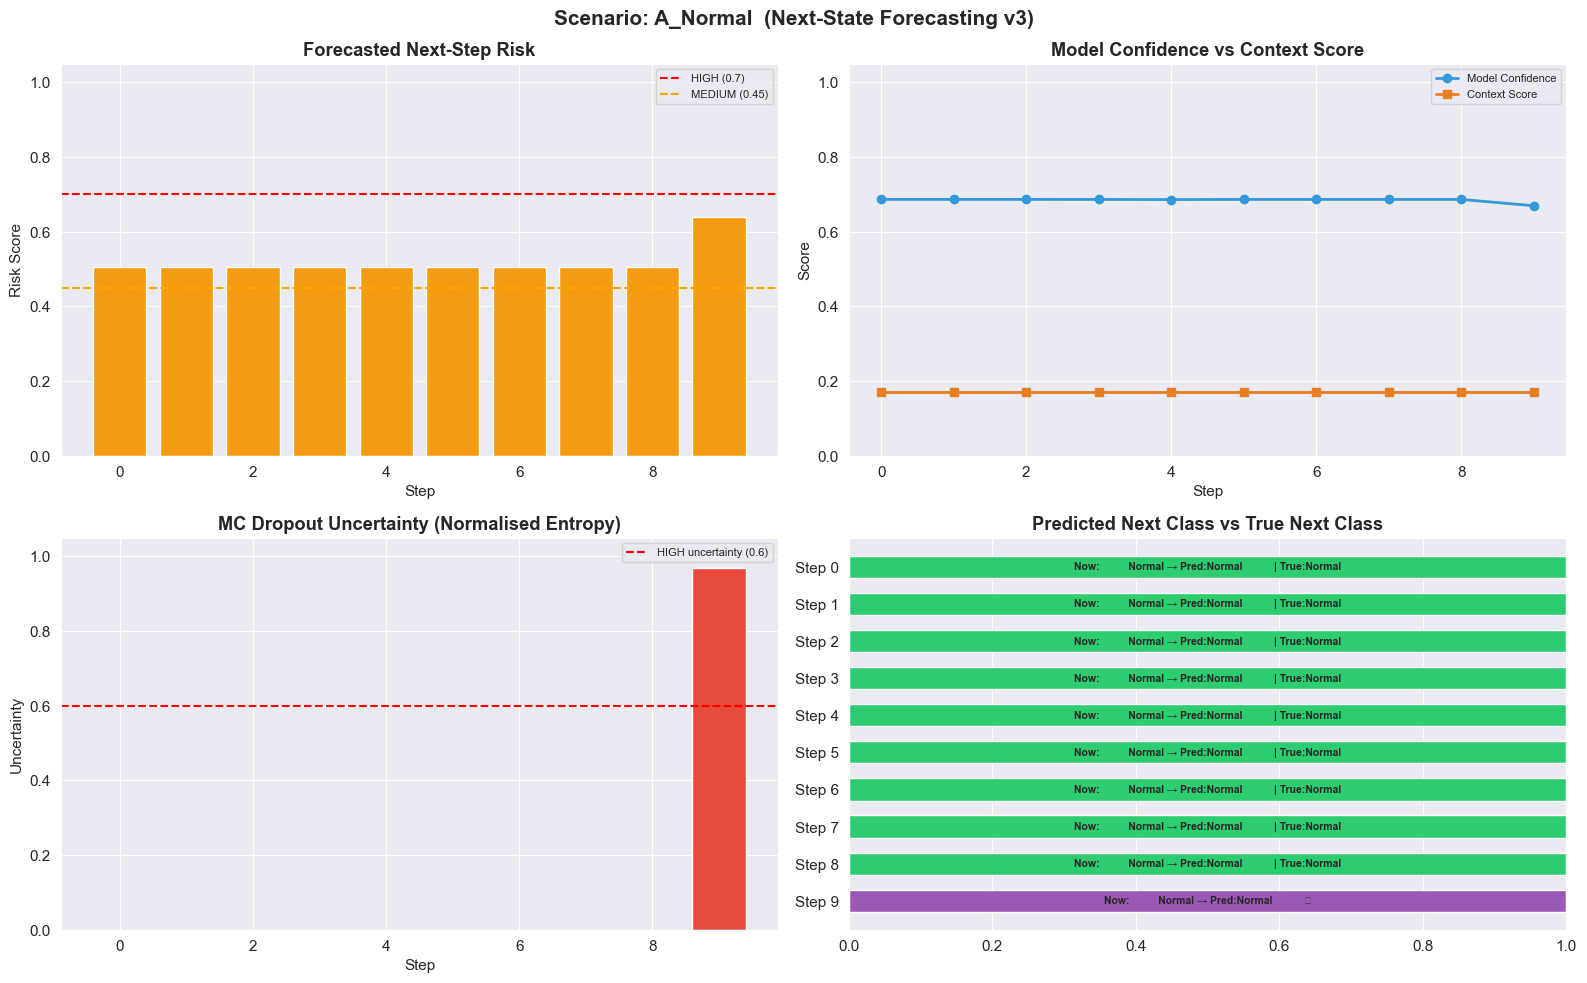

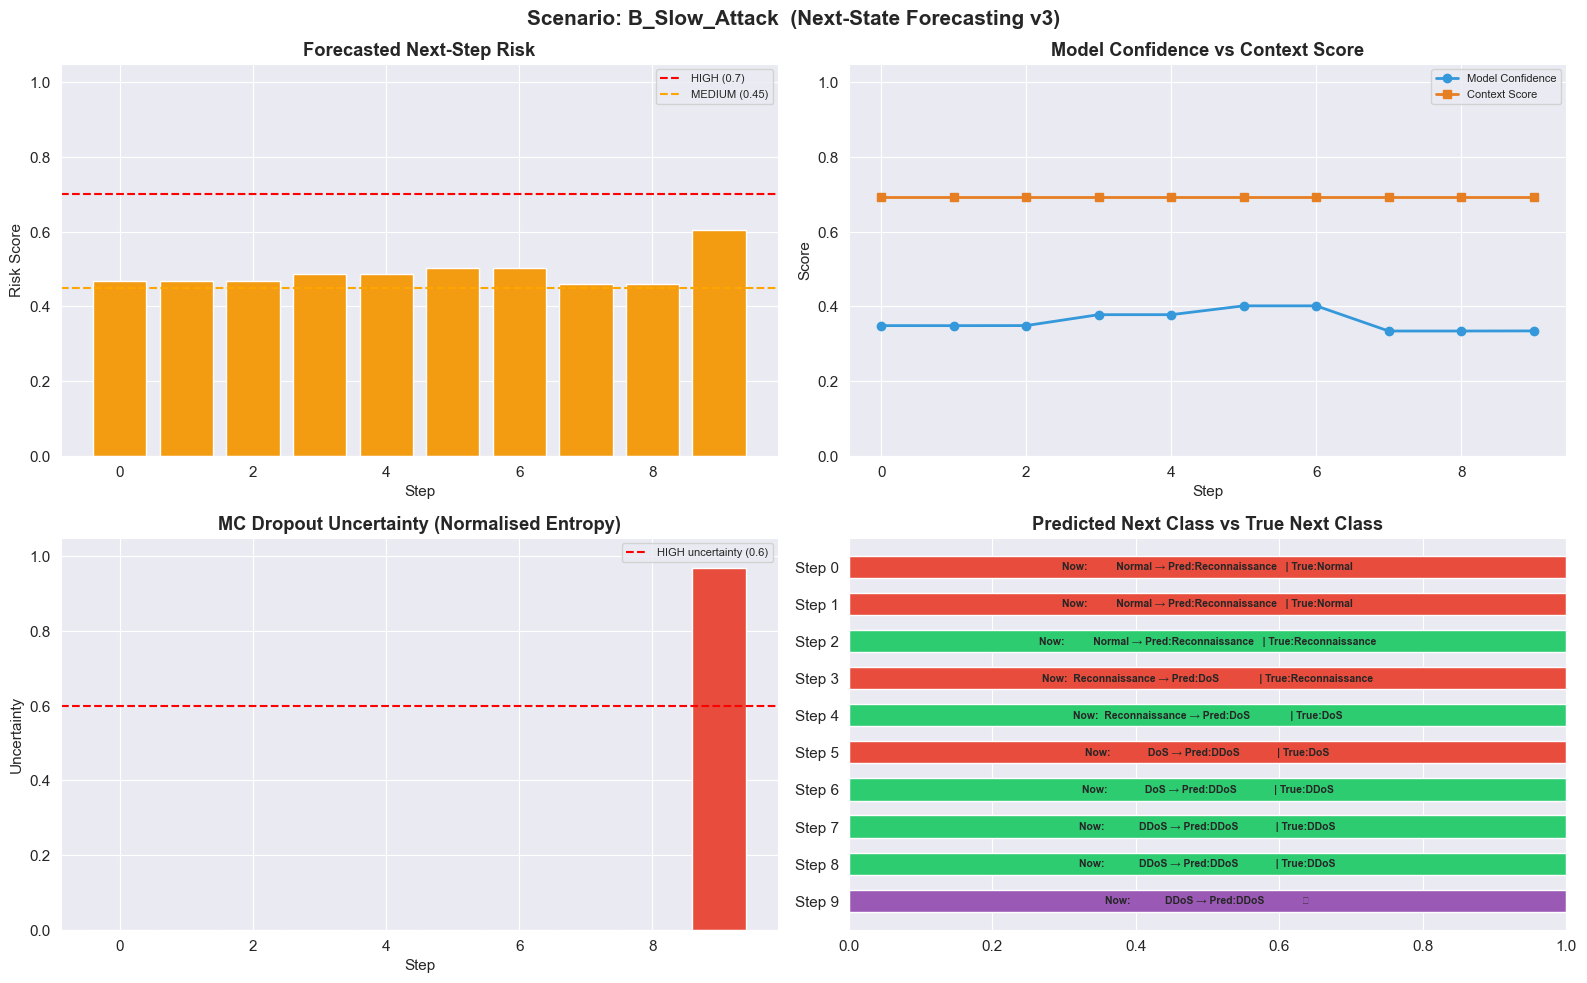

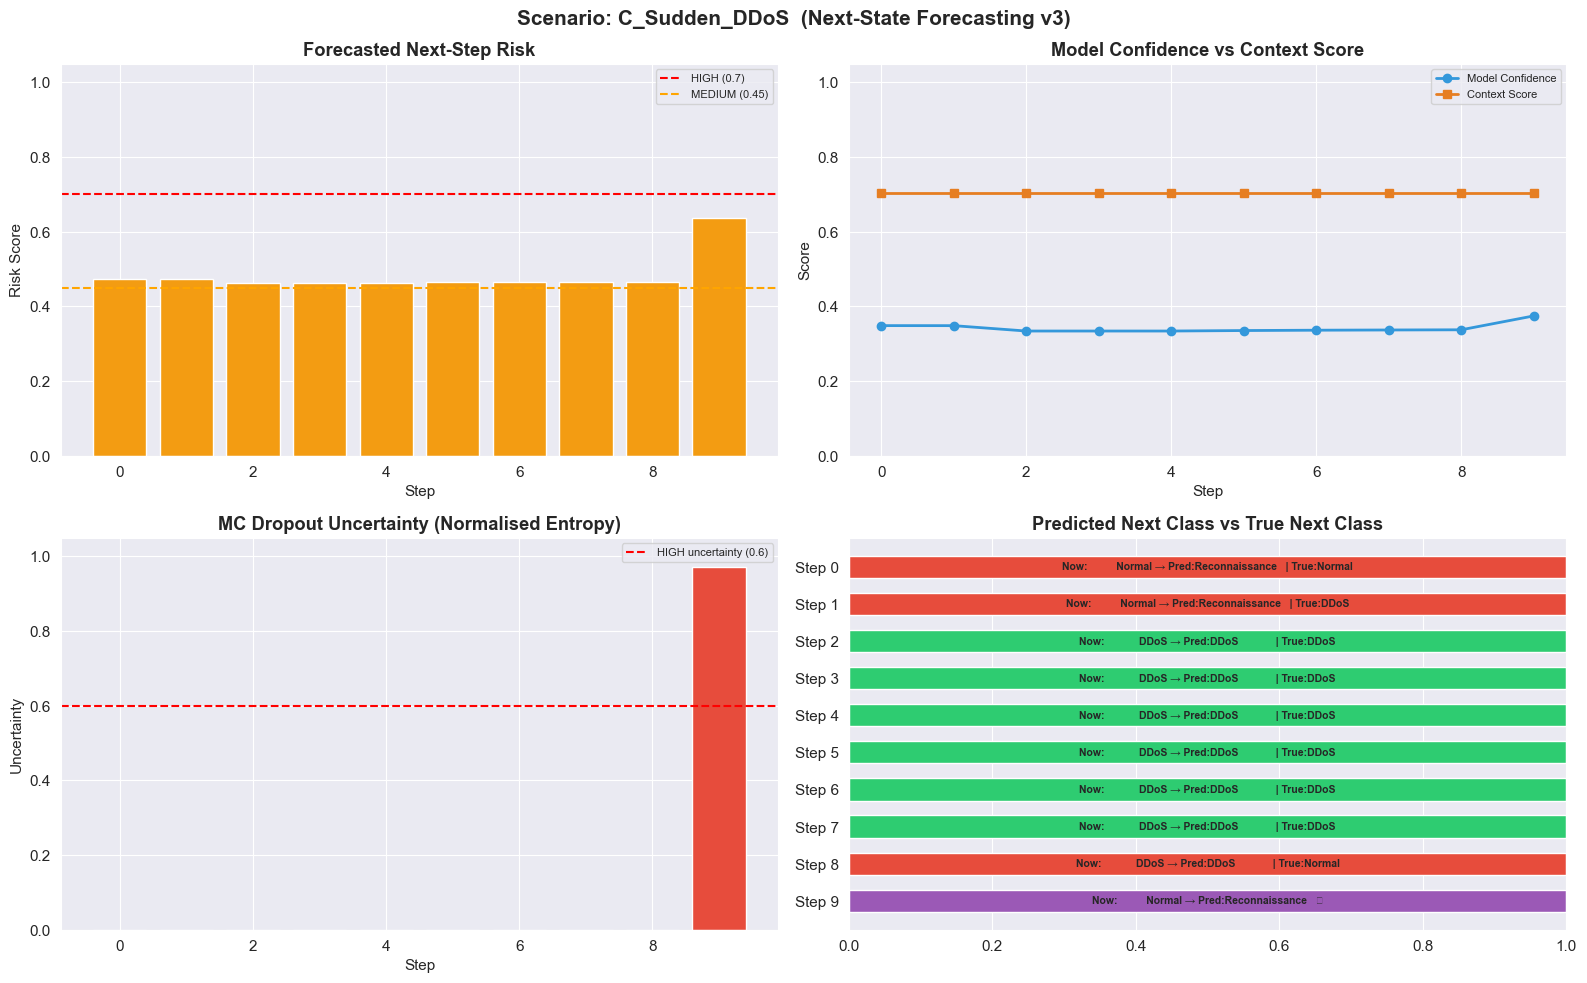

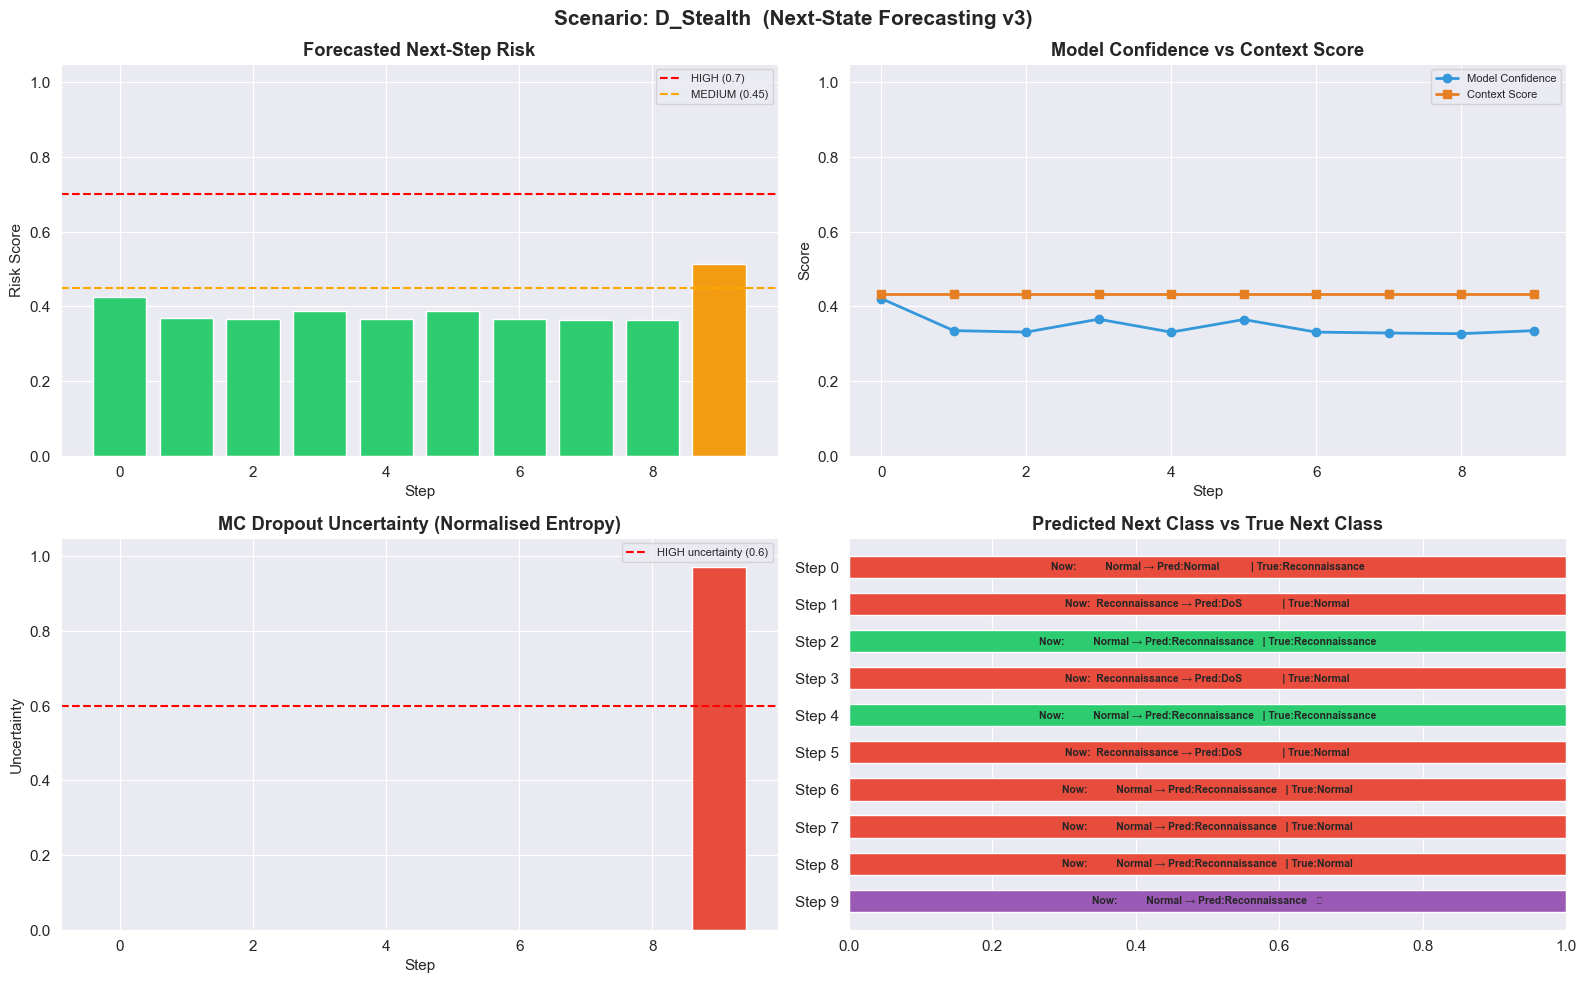

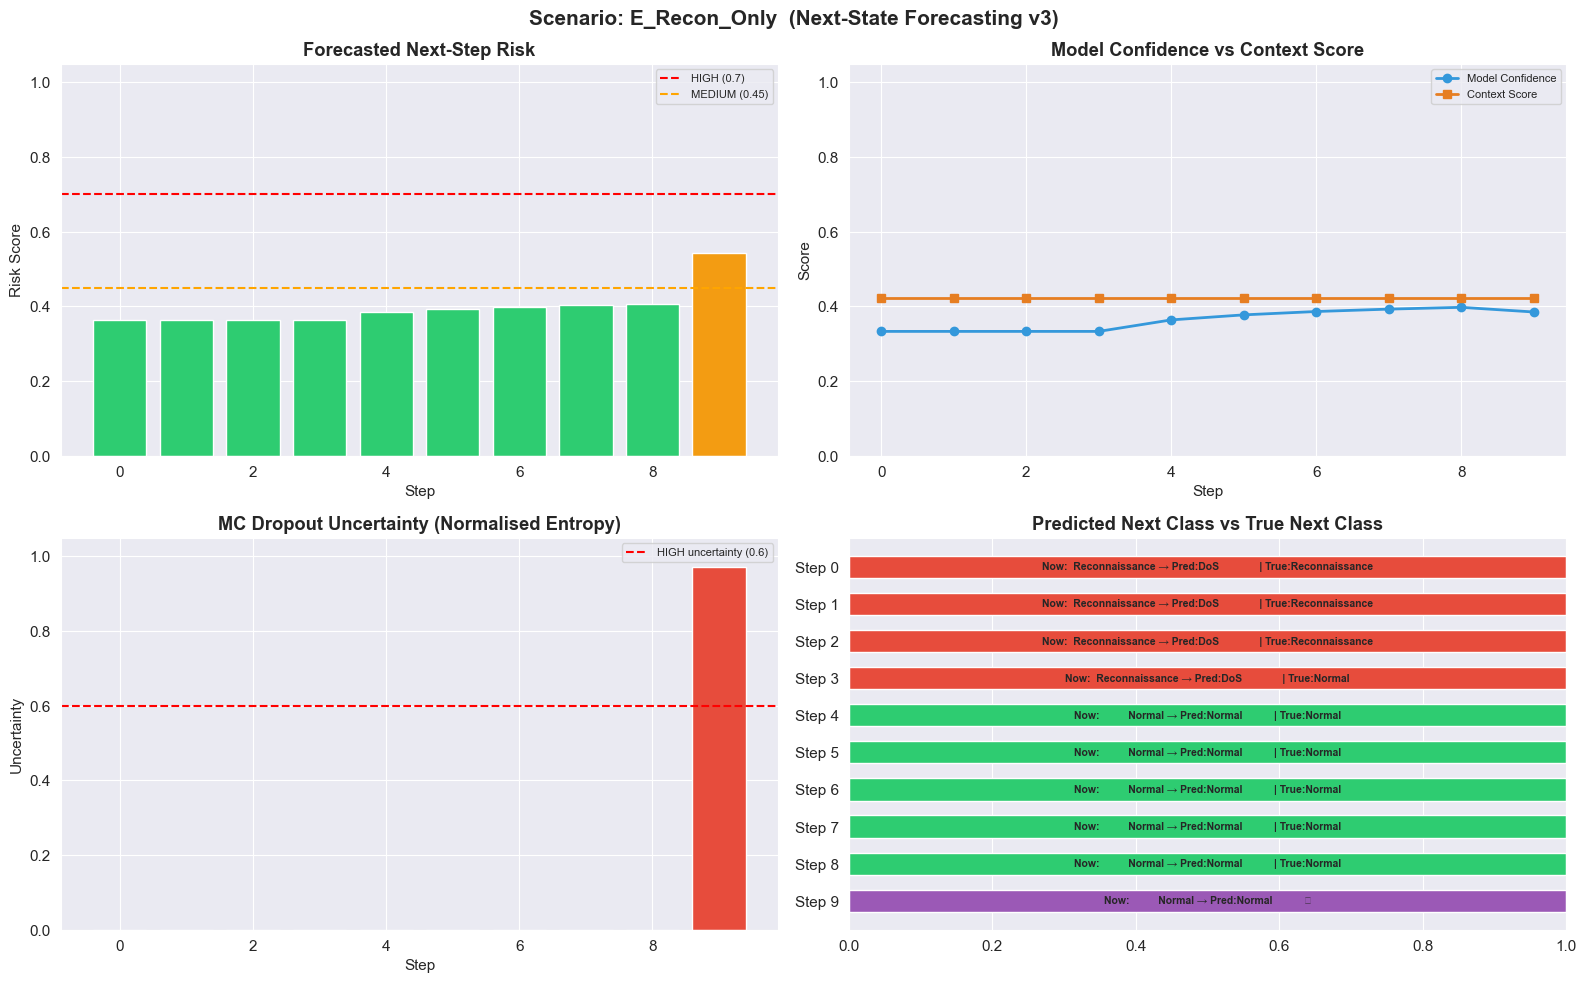

In [39]:
def plot_scenario_dashboard(scenario_name, results):
    """4-panel dashboard for one scenario showing next-state forecasting metrics."""
    n         = len(results)
    steps     = list(range(n))
    risks     = [r['final_risk']     for r in results]
    confs     = [r['model_confidence'] for r in results]
    ctxs      = [r['context_score']   for r in results]
    uncs      = [r['uncertainty']     for r in results]
    curr_cls  = [r['current_class']   for r in results]
    pred_next = [r['predicted_next_class'] for r in results]
    true_next = [r['true_next_class'] for r in results]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Scenario: {scenario_name}  (Next-State Forecasting v3)',
                 fontsize=15, fontweight='bold')

    # Panel 1 — Final risk
    ax = axes[0, 0]
    colors = ['#e74c3c' if r >= THRESHOLD else '#f39c12' if r >= 0.45 else '#2ecc71' for r in risks]
    ax.bar(steps, risks, color=colors)
    ax.axhline(THRESHOLD, color='red',    ls='--', lw=1.5, label=f'HIGH ({THRESHOLD})')
    ax.axhline(0.45,      color='orange', ls='--', lw=1.5, label='MEDIUM (0.45)')
    ax.set_title('Forecasted Next-Step Risk', fontweight='bold')
    ax.set_xlabel('Step'); ax.set_ylabel('Risk Score')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

    # Panel 2 — Confidence vs Context
    ax = axes[0, 1]
    ax.plot(steps, confs, 'o-', color='#3498db', label='Model Confidence', linewidth=2)
    ax.plot(steps, ctxs,  's-', color='#e67e22', label='Context Score',    linewidth=2)
    ax.set_title('Model Confidence vs Context Score', fontweight='bold')
    ax.set_xlabel('Step'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

    # Panel 3 — MC Dropout uncertainty
    ax = axes[1, 0]
    unc_colors = ['#e74c3c' if u >= UNCERTAINTY_HIGH_THRESHOLD else '#3498db' for u in uncs]
    ax.bar(steps, uncs, color=unc_colors)
    ax.axhline(UNCERTAINTY_HIGH_THRESHOLD, color='red', ls='--', lw=1.5,
               label=f'HIGH uncertainty ({UNCERTAINTY_HIGH_THRESHOLD})')
    ax.set_title('MC Dropout Uncertainty (Normalised Entropy)', fontweight='bold')
    ax.set_xlabel('Step'); ax.set_ylabel('Uncertainty')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

    # Panel 4 — Prediction vs truth
    ax = axes[1, 1]
    for i in range(n):
        if true_next[i] == '(FORECAST)':
            color = '#9b59b6'
            lbl   = f'Now:{curr_cls[i]!s:>16} → Pred:{pred_next[i]!s:<16} 🔮'
        else:
            correct = (pred_next[i] == true_next[i])
            color   = '#2ecc71' if correct else '#e74c3c'
            lbl     = f'Now:{curr_cls[i]!s:>16} → Pred:{pred_next[i]!s:<16} | True:{true_next[i]}'
        ax.barh(i, 1, color=color, edgecolor='white', height=0.6)
        ax.text(0.5, i, lbl, ha='center', va='center', fontsize=7.5, fontweight='bold')
    ax.set_yticks(steps)
    ax.set_yticklabels([f'Step {i}' for i in steps])
    ax.set_title('Predicted Next Class vs True Next Class', fontweight='bold')
    ax.set_xlim(0, 1); ax.invert_yaxis()

    plt.tight_layout(); plt.show()

for name, results in all_results.items():
    plot_scenario_dashboard(name, results)


### Cell Ph6-11 — Multi-Step Markov Lookahead Demo

Shows that the system can predict DDoS threats *multiple steps ahead*,
not just one step. This directly addresses the FYP goal of **proactive** defense.


In [40]:
def print_forecasting_lookahead(trail, scenario_name, n_lookahead=3):
    """
    Walk through a scenario trail and show at each step:
      - Current prediction
      - Markov lookahead for t+1, t+2, t+3
      - Whether a future attack was flagged BEFORE it happened
    """
    ATTACK_CLASSES = {'DDoS', 'DoS', 'Reconnaissance'}
    print(f"\n{'═'*80}")
    print(f"  MULTI-STEP LOOKAHEAD — {scenario_name}  ({n_lookahead}-step ahead)")
    print(f"{'═'*80}")
    print(f"  {'t':<4} {'Current':<16} {'Pred Next':<16} {'Alert':<8}  Lookahead: t+1 | t+2 | t+3")
    print(f"  {'─'*3} {'─'*15} {'─'*15} {'─'*7}  {'─'*45}")

    early_warnings = []

    for r in trail:
        t         = r['step']
        pred      = r['predicted_next_class']
        alert     = r['alert_level']
        curr_cls  = r['current_class']
        true_next = r['true_next_class']

        forecasts = markov_forecast_lookahead(pred, n_steps=n_lookahead)

        fc_parts = []
        warned   = False
        for offset, dist in forecasts:
            # top non-Normal class if any
            attack_dist = {k: v for k, v in dist.items() if k in ATTACK_CLASSES}
            if attack_dist:
                top_cls  = max(attack_dist, key=attack_dist.get)
                top_prob = attack_dist[top_cls]
                fc_parts.append(f"{top_cls[:4]}@t+{offset}={top_prob:.2f}")
                if top_prob >= 0.25:
                    warned = True
            else:
                fc_parts.append(f"Norm@t+{offset}")

        if warned and true_next in ATTACK_CLASSES:
            early_warnings.append(t)

        warning_flag = " ⚠ EARLY WARNING" if warned else ""
        print(f"  t{t:<3} {curr_cls:<16} {pred:<16} {alert:<8}  {'  |  '.join(fc_parts)}{warning_flag}")

    if early_warnings:
        print(f"\n  ⚡ Early warnings issued at steps: {early_warnings}")
    else:
        print(f"\n  ✅ No attack escalation predicted in this scenario")


# Run on the B_Slow_Attack and C_Sudden_DDoS scenarios — most interesting for lookahead
for sc in ['B_Slow_Attack', 'C_Sudden_DDoS', 'D_Stealth']:
    print_forecasting_lookahead(all_results[sc], sc, n_lookahead=3)



════════════════════════════════════════════════════════════════════════════════
  MULTI-STEP LOOKAHEAD — B_Slow_Attack  (3-step ahead)
════════════════════════════════════════════════════════════════════════════════
  t    Current          Pred Next        Alert     Lookahead: t+1 | t+2 | t+3
  ─── ─────────────── ─────────────── ───────  ─────────────────────────────────────────────
  t0   Normal           Reconnaissance   MEDIUM    Reco@t+1=0.47  |  Reco@t+2=0.36  |  Reco@t+3=0.33 ⚠ EARLY WARNING
  t1   Normal           Reconnaissance   MEDIUM    Reco@t+1=0.47  |  Reco@t+2=0.36  |  Reco@t+3=0.33 ⚠ EARLY WARNING
  t2   Normal           Reconnaissance   MEDIUM    Reco@t+1=0.47  |  Reco@t+2=0.36  |  Reco@t+3=0.33 ⚠ EARLY WARNING
  t3   Reconnaissance   DoS              MEDIUM    DoS@t+1=0.46  |  DoS@t+2=0.35  |  DoS@t+3=0.33 ⚠ EARLY WARNING
  t4   Reconnaissance   DoS              MEDIUM    DoS@t+1=0.46  |  DoS@t+2=0.35  |  DoS@t+3=0.33 ⚠ EARLY WARNING
  t5   DoS              DDoS    

### Cell Ph6-12 — Forecast Accuracy Summary Table


📊 NEXT-STATE FORECAST SUMMARY
     Scenario  Steps  Forecastable  Correct Forecast Acc  HIGH Alerts  MED Alerts Avg Risk Avg Uncertainty Avg TL
     A_Normal     10             9        9         100%            0          10    0.519           0.097  0.255
B_Slow_Attack     10             9        5          56%            0          10    0.491           0.097  0.935
C_Sudden_DDoS     10             9        6          67%            0          10    0.483           0.097  0.933
    D_Stealth     10             9        2          22%            0           1    0.391           0.097  0.807
 E_Recon_Only     10             9        5          56%            0           1    0.399           0.097  0.673


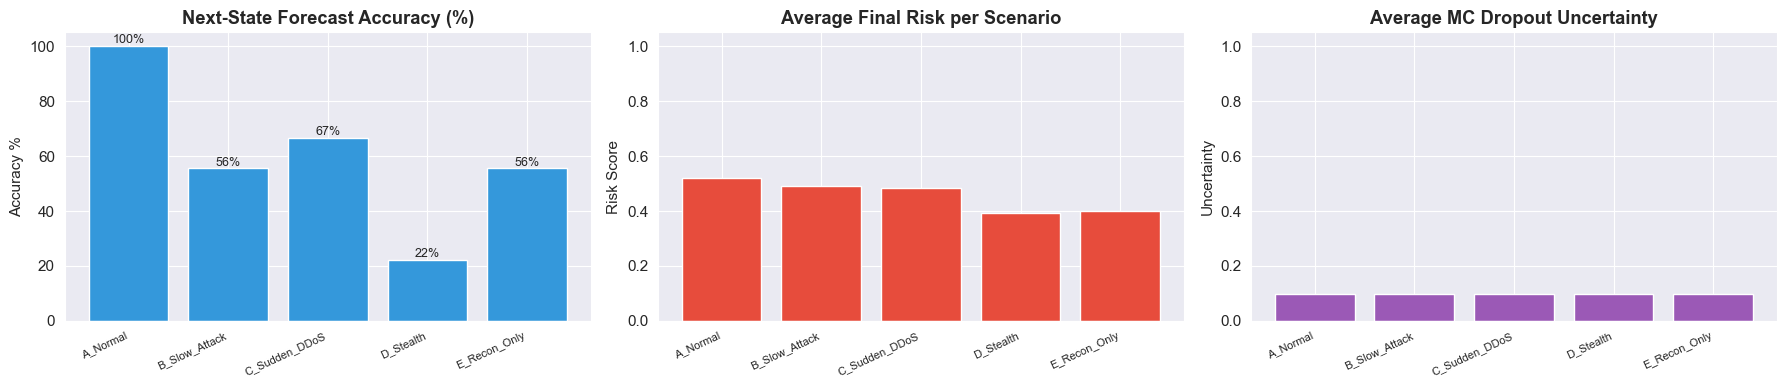

In [41]:
summary_rows = []
for name, results in all_results.items():
    valid   = [r for r in results if r['true_next_class'] != '(FORECAST)']
    n_corr  = sum(1 for r in valid if r['predicted_next_class'] == r['true_next_class'])
    n_v     = len(valid)
    n_high  = sum(1 for r in results if r['alert_level'] == 'HIGH')
    n_med   = sum(1 for r in results if r['alert_level'] == 'MEDIUM')
    avg_r   = np.mean([r['final_risk']   for r in results])
    avg_u   = np.mean([r['uncertainty']  for r in results])
    avg_tl  = np.mean([r['transition_likelihood'] for r in results])
    summary_rows.append({
        'Scenario'        : name,
        'Steps'           : len(results),
        'Forecastable'    : n_v,
        'Correct'         : n_corr,
        'Forecast Acc'    : f'{n_corr/n_v*100:.0f}%' if n_v else 'N/A',
        'HIGH Alerts'     : n_high,
        'MED Alerts'      : n_med,
        'Avg Risk'        : f'{avg_r:.3f}',
        'Avg Uncertainty' : f'{avg_u:.3f}',
        'Avg TL'          : f'{avg_tl:.3f}',
    })

summary_df = pd.DataFrame(summary_rows)
print("\n📊 NEXT-STATE FORECAST SUMMARY")
print(summary_df.to_string(index=False))

# Quick bar chart of accuracy per scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
names_list = list(all_results.keys())

accs  = []
risks = []
uncs  = []
for name in names_list:
    results = all_results[name]
    valid   = [r for r in results if r['true_next_class'] != '(FORECAST)']
    n_corr  = sum(1 for r in valid if r['predicted_next_class'] == r['true_next_class'])
    accs.append(n_corr / len(valid) * 100 if valid else 0)
    risks.append(np.mean([r['final_risk']  for r in results]))
    uncs.append( np.mean([r['uncertainty'] for r in results]))

axes[0].bar(names_list, accs, color='#3498db')
axes[0].set_title('Next-State Forecast Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy %'); axes[0].set_ylim(0, 105)
for i, v in enumerate(accs): axes[0].text(i, v+1, f'{v:.0f}%', ha='center', fontsize=9)

axes[1].bar(names_list, risks, color='#e74c3c')
axes[1].set_title('Average Final Risk per Scenario', fontweight='bold')
axes[1].set_ylabel('Risk Score'); axes[1].set_ylim(0, 1.05)

axes[2].bar(names_list, uncs, color='#9b59b6')
axes[2].set_title('Average MC Dropout Uncertainty', fontweight='bold')
axes[2].set_ylabel('Uncertainty'); axes[2].set_ylim(0, 1.05)

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.tight_layout(); plt.show()


### Cell Ph6-13 — Interactive Reviewer Demo

Complete live demo of the full pipeline on a realistic escalating attack scenario.
Shows every step: XGBoost → LSTM (MC Dropout) → Adaptive Markov → Context → Decision → Proactive Actions.


In [42]:
def run_reviewer_demo():
    """
    End-to-end forecasting demo on a realistic escalating attack.
    At each step t: observes current traffic class → forecasts t+1 → issues proactive defense.
    """
    print("=" * 72)
    print("  🔒 CONTEXT-AWARE CYBER THREAT FORECASTING — FINAL DEMO")
    print("     Pipeline: XGBoost + LSTM (MC Dropout) + Adaptive Markov v3")
    print("     Goal: FORECAST the NEXT threat class → proactive defense")
    print("=" * 72)

    demo_seq = ['Normal', 'Normal', 'Reconnaissance', 'Reconnaissance',
                'DoS', 'DoS', 'DDoS', 'DDoS', 'DDoS', 'Normal']
    demo_ctx = dict(hour=2, device_type='server', pkts_per_sec=850,
                    unique_dsts=42, repeat_count=3, country_code='RU')

    print(f"\n  Scenario : {demo_seq}")
    print(f"  Context  : {demo_ctx}\n")
    print("-" * 72)

    xgb_history   = deque(maxlen=WINDOW)
    lstm_history  = deque(maxlen=WINDOW)
    state_history = []
    n_correct = 0; n_valid = 0

    for step, cls_name in enumerate(demo_seq):
        state_history.append(cls_name)
        xgb_proba = simulate_window(cls_name, step)
        xgb_history.append(xgb_proba)
        lstm_history.append(xgb_proba)

        if len(lstm_history) >= WINDOW:
            lstm_inp = np.array(list(lstm_history)).reshape(1, WINDOW, n_classes)
            lstm_proba, uncertainty, _ = lstm_predict_mc(lstm_inp)
        else:
            lstm_proba = np.ones(n_classes) / n_classes; uncertainty = 0.0

        csi    = le.transform([cls_name])[0]
        result = decision_engine_v3(
            xgb_proba, lstm_proba, csi, step,
            context_kwargs=demo_ctx, uncertainty=uncertainty,
            state_history=state_history, xgb_history=xgb_history,
        )

        if step < len(demo_seq) - 1:
            true_next = demo_seq[step + 1]
            ok        = '✅' if result['predicted_next_class'] == true_next else '❌'
            n_valid += 1; n_correct += (1 if result['predicted_next_class'] == true_next else 0)
        else:
            true_next = '(END — pure forecast)'; ok = '🔮'

        alert_icon = {'HIGH': '🔴', 'MEDIUM': '🟠', 'LOW': '🟢'}[result['alert_level']]
        cnames = [str(c) for c in class_names]

        print(f"  STEP {step}")
        print(f"  ├─ Current Class        : {cls_name}")
        print(f"  ├─ Predicted NEXT       : {result['predicted_next_class']} {ok}")
        print(f"  ├─ True NEXT            : {true_next}")
        print(f"  ├─ Transition Likelihood: {result['transition_likelihood']:.4f}")
        print(f"  ├─ Adaptive Markov      : {dict(zip(cnames, result['adaptive_markov']))}")
        print(f"  ├─ Model Confidence     : {result['model_confidence']:.4f}")
        print(f"  ├─ Context Score        : {result['context_score']:.4f}")
        print(f"  ├─ XGB Trend Divergence : {result['xgb_trend_divergence']:.4f}")
        print(f"  ├─ Uncertainty (MC)     : {result['uncertainty']:.4f}  [{result['uncertainty_flag']}]")
        print(f"  ├─ Final Risk           : {result['final_risk']:.4f}")
        print(f"  ├─ Alert Level          : {alert_icon} {result['alert_level']}")
        print(f"  └─ Proactive Actions    : {chr(10).join('    • ' + a for a in result['actions'])}")
        print()

    print("-" * 72)
    acc = n_correct / n_valid * 100 if n_valid else 0
    print(f"  📊 Next-State Forecast Accuracy : {n_correct}/{n_valid} ({acc:.0f}%)")
    print("=" * 72)
    print("  DEMO COMPLETE — System forecasts the NEXT threat step proactively.")
    print("  Architecture: XGBoost + LSTM (MC Dropout) + Adaptive Markov v3")
    print("               + Escalation Prior + Trend Detection + Context Engine")
    print("=" * 72)


run_reviewer_demo()


  🔒 CONTEXT-AWARE CYBER THREAT FORECASTING — FINAL DEMO
     Pipeline: XGBoost + LSTM (MC Dropout) + Adaptive Markov v3
     Goal: FORECAST the NEXT threat class → proactive defense

  Scenario : ['Normal', 'Normal', 'Reconnaissance', 'Reconnaissance', 'DoS', 'DoS', 'DDoS', 'DDoS', 'DDoS', 'Normal']
  Context  : {'hour': 2, 'device_type': 'server', 'pkts_per_sec': 850, 'unique_dsts': 42, 'repeat_count': 3, 'country_code': 'RU'}

------------------------------------------------------------------------
  STEP 0
  ├─ Current Class        : Normal
  ├─ Predicted NEXT       : Reconnaissance ❌
  ├─ True NEXT            : Normal
  ├─ Transition Likelihood: 0.9000
  ├─ Adaptive Markov      : {'DDoS': 0.1738, 'DoS': 0.2329, 'Normal': 0.2044, 'Reconnaissance': 0.3888}
  ├─ Model Confidence     : 0.3485
  ├─ Context Score        : 0.6788
  ├─ XGB Trend Divergence : 0.0000
  ├─ Uncertainty (MC)     : 0.0000  [LOW]
  ├─ Final Risk           : 0.4641
  ├─ Alert Level          : 🟠 MEDIUM
  └─ Proacti